<h1 style="
    background-color: #ebb338;
    color: white;
    padding: 10px;
    text-align: left;
    font-family: Arial, sans-serif;
    font-size: 32px;
    font-weight: bold;
    margin: 10px 0;">
    Análise dataset ZnO - <span style="color: #32668d;">SBPMAT</span>
</h1>

In [6]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from ase import units

In [7]:
# Abrindo o dataset 
db_atomo = pd.read_csv('../../data/dataset_long.csv')
db_simulacao = pd.read_csv('../../data/dataset_wide.csv')

In [8]:
scientific_theme_path: str = r"/home/jvc/QEspresso7.2/ZnO_database/mpl_themes/computermodern.mplstyle"
plt.style.use(scientific_theme_path)

# 
<h2 style="
    background-color: #251351; 
    color: white; 
    padding: 10px; 
    text-align: left; 
    font-family: Arial, sans-serif; 
    font-size: 32px; 
    font-weight: bold; 
    margin: 10px 0;">
    Distribuição de Forças
</h2>  

- Usar o dataset do tipo long.
- Remover colunas desnecessárias
- Decidir se plot por supercélula, ou por parâmetros de rede.



In [9]:
# Critérios de Convergência das Forças: https://www.quantum-espresso.org/Doc/INPUT_PW.html#idm124
conv_atomic_units = 1e-3
conv_eV_A = conv_atomic_units * (units.Ry / units.Bohr)

print(f"Convergência em (a.u) {conv_atomic_units} Ry/bohr")
print(f"Convergência em eV/Å : {conv_eV_A:.5f} ")


db_atomo[['modulo_eV_A']] > conv

Convergência em (a.u) 0.001 Ry/bohr
Convergência em eV/Å : 0.02571 


NameError: name 'conv' is not defined

In [ ]:
# Critérios de Convergência das Forças: https://www.quantum-espresso.org/Doc/INPUT_PW.html#idm124
conv_atomic_units = 1e-3
conv_eV_A = conv_atomic_units * (units.Ry / units.Bohr)

print(f"Convergência em (a.u): {conv_atomic_units} Ry/bohr")
print(f"Convergência em eV/Å : {conv_eV_A:.5f} eV/Å")

# Criar máscara booleana para átomos que respeitam o critério de convergência
mask_converged = db_atomo["modulo_eV_A"] <= conv_eV_A
mask_not_converged = ~mask_converged

# Contagem
n_total = len(db_atomo)
n_converged = mask_converged.sum()
n_not_converged = mask_not_converged.sum()

print(f"Total de átomos no dataset : {n_total}")
print(f"Átomos convergidos (<= {conv_eV_A:.5f} eV/Å): {n_converged}  ({n_converged/n_total:.2%})")
print(f"Átomos não convergidos      : {n_not_converged}  ({n_not_converged/n_total:.2%})")

# Opcional: criar coluna booleana no DataFrame
db_atomo["converged"] = mask_converged


Convergência em (a.u): 0.001 Ry/bohr
Convergência em eV/Å : 0.02571 eV/Å
Total de átomos no dataset : 43560
Átomos convergidos (<= 0.02571 eV/Å): 4680  (10.74%)
Átomos não convergidos      : 38880  (89.26%)


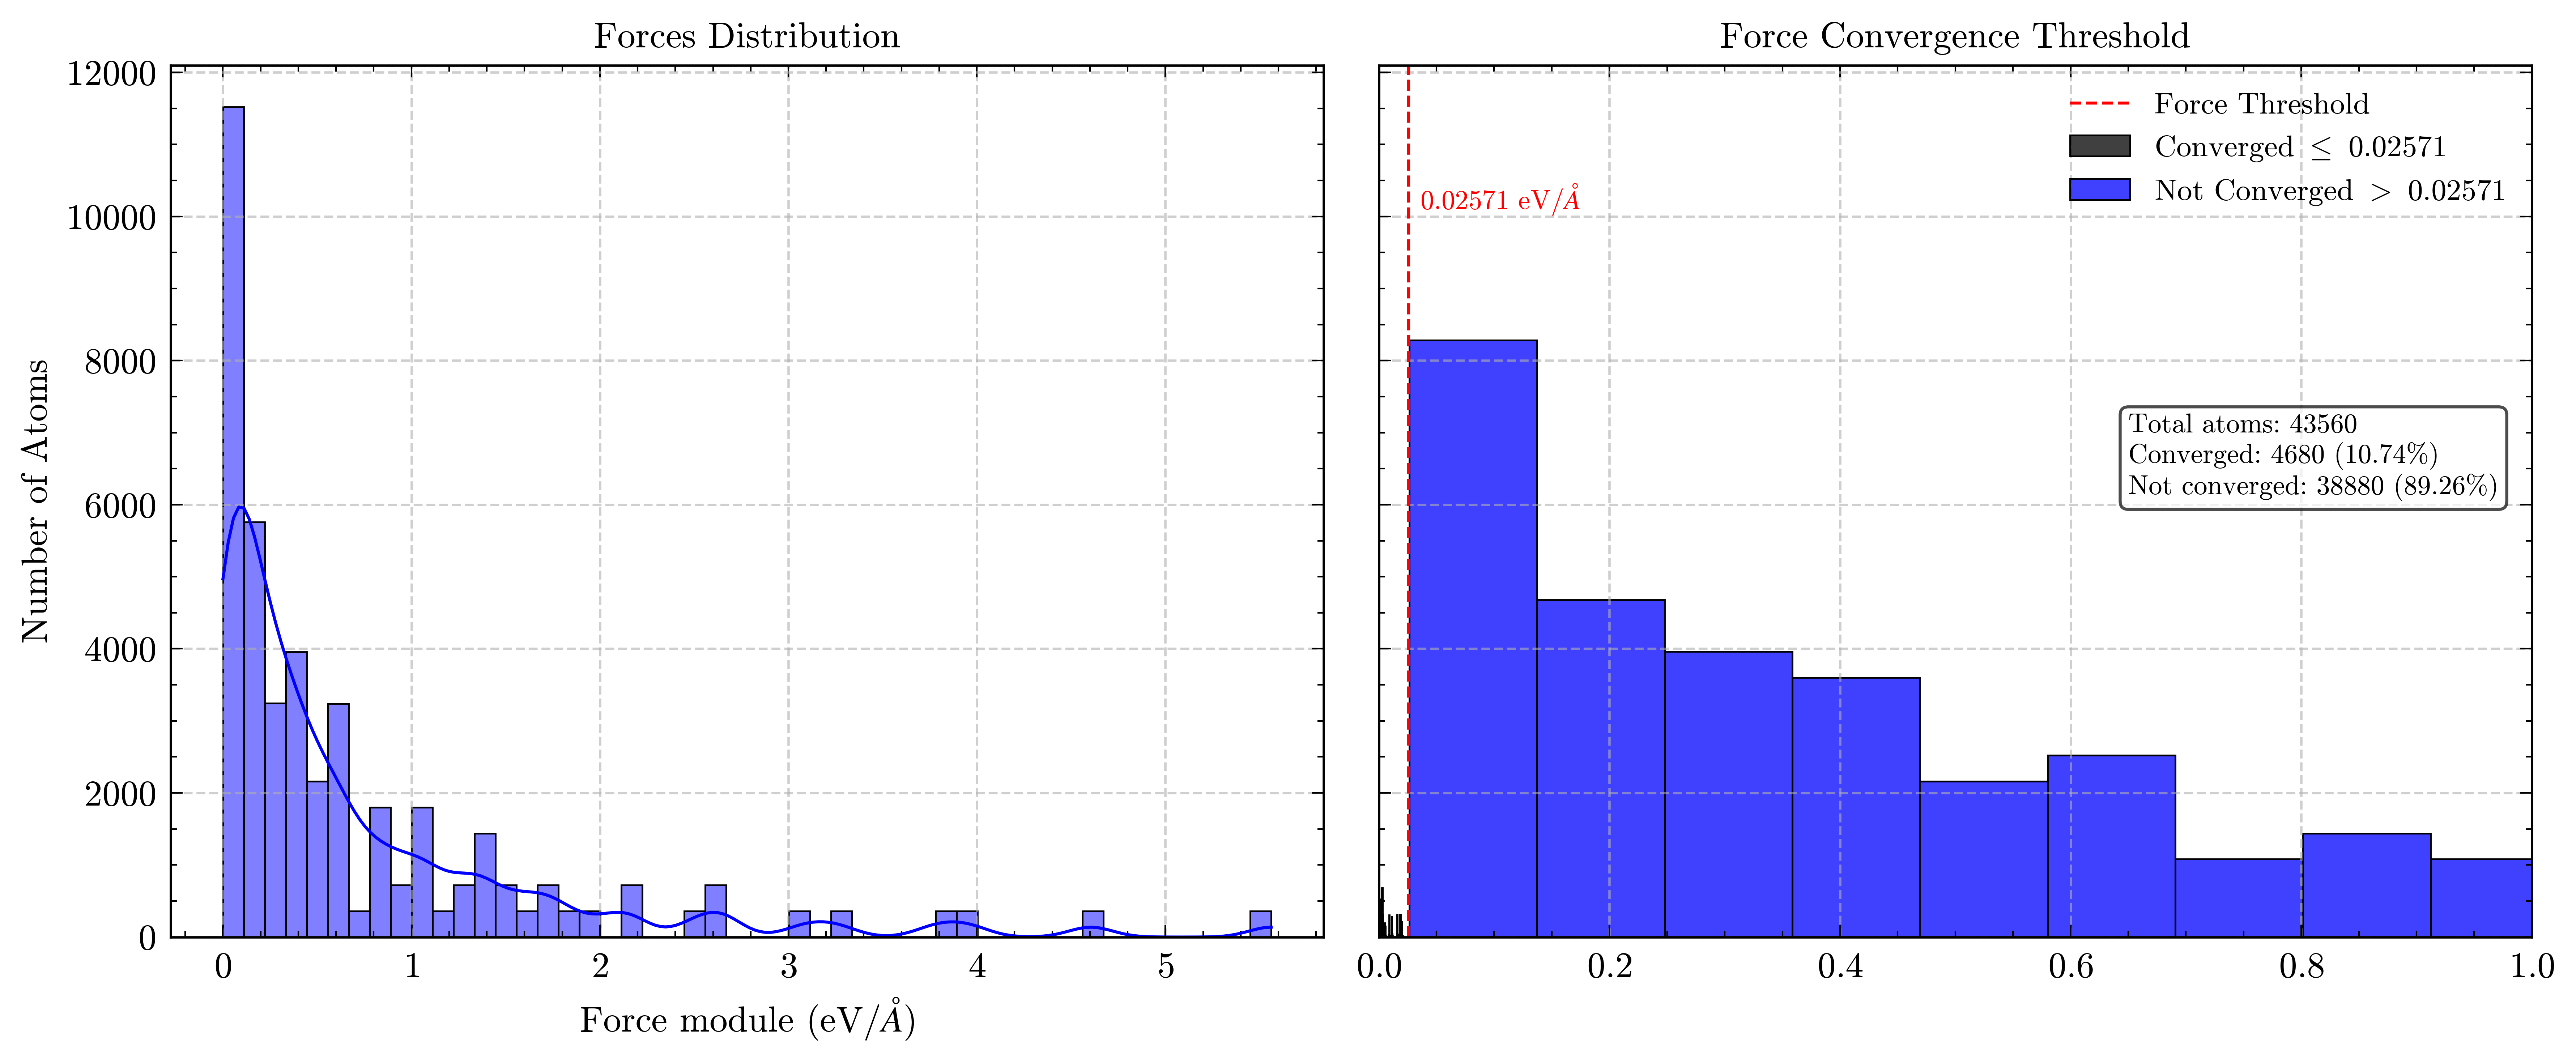

In [ ]:
# Máscaras
mask_converged = db_atomo["modulo_eV_A"] <= conv_eV_A
mask_not_converged = ~mask_converged

# Contagens
n_total = len(db_atomo)
n_converged = mask_converged.sum()
n_not_converged = mask_not_converged.sum()

perc_converged = 100 * n_converged / n_total
perc_not_converged = 100 * n_not_converged / n_total

# Texto com estatísticas
textstr = (
    f"Total atoms: {n_total}\n"
    f"Converged: {n_converged} ({perc_converged:.2f}%)\n"
    f"Not converged: {n_not_converged} ({perc_not_converged:.2f}%)"
)

# Gráficos
fig, ax = plt.subplots(1, 2, figsize=(12,5), sharey=True, dpi=600)

# Distribuição geral
sns.histplot(db_atomo['modulo_eV_A'], kde=True, bins=50, ax=ax[0], color="blue")
ax[0].set_title("Forces Distribution")
ax[0].set_xlabel("Force module (eV/$\\AA$)")
ax[0].set_ylabel("Number of Atoms")
ax[0].grid(True, linestyle="--", alpha=0.6)

# Distribuição com zoom + cores convergido/não
sns.histplot(db_atomo.loc[mask_converged, 'modulo_eV_A'], 
             bins=50, kde=False, ax=ax[1], color="black", label=f"Converged $\\leq$ {conv_eV_A:.5f}")
sns.histplot(db_atomo.loc[mask_not_converged, 'modulo_eV_A'], 
             bins=50, kde=False, ax=ax[1], color="blue", label=f"Not Converged $>$ {conv_eV_A:.5f}")

# Linha do threshold
ax[1].axvline(conv_eV_A, color='red', ls='--', label="Force Threshold")

# Configurações do subplot direito
ax[1].set_title("Force Convergence Threshold")
ax[1].set_xlim(0, 1)
ax[1].set_xlabel("")
ax[1].grid(True, linestyle="--", alpha=0.6)

# Caixa com estatísticas no canto inferior direito
ax[1].text(0.65, 0.5, textstr, transform=ax[1].transAxes,
           fontsize=9, verticalalignment='bottom', horizontalalignment='left',
           bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

# Encontrar altura da maior barra no histograma com zoom
counts, bins = np.histogram(db_atomo['modulo_eV_A'], bins=50, range=(0,1))
ymax = counts.max()

# Texto com valor do threshold, próximo da linha vermelha
ax[1].text(conv_eV_A+0.01, 10_000, f"{conv_eV_A:.5f} eV/$\\AA$", 
           color="red", fontsize=9, ha="left", va="bottom",
           rotation=0)

# Legenda só para cores/linhas
ax[1].legend(loc="upper right")
plt.savefig('forces_dist.png', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()


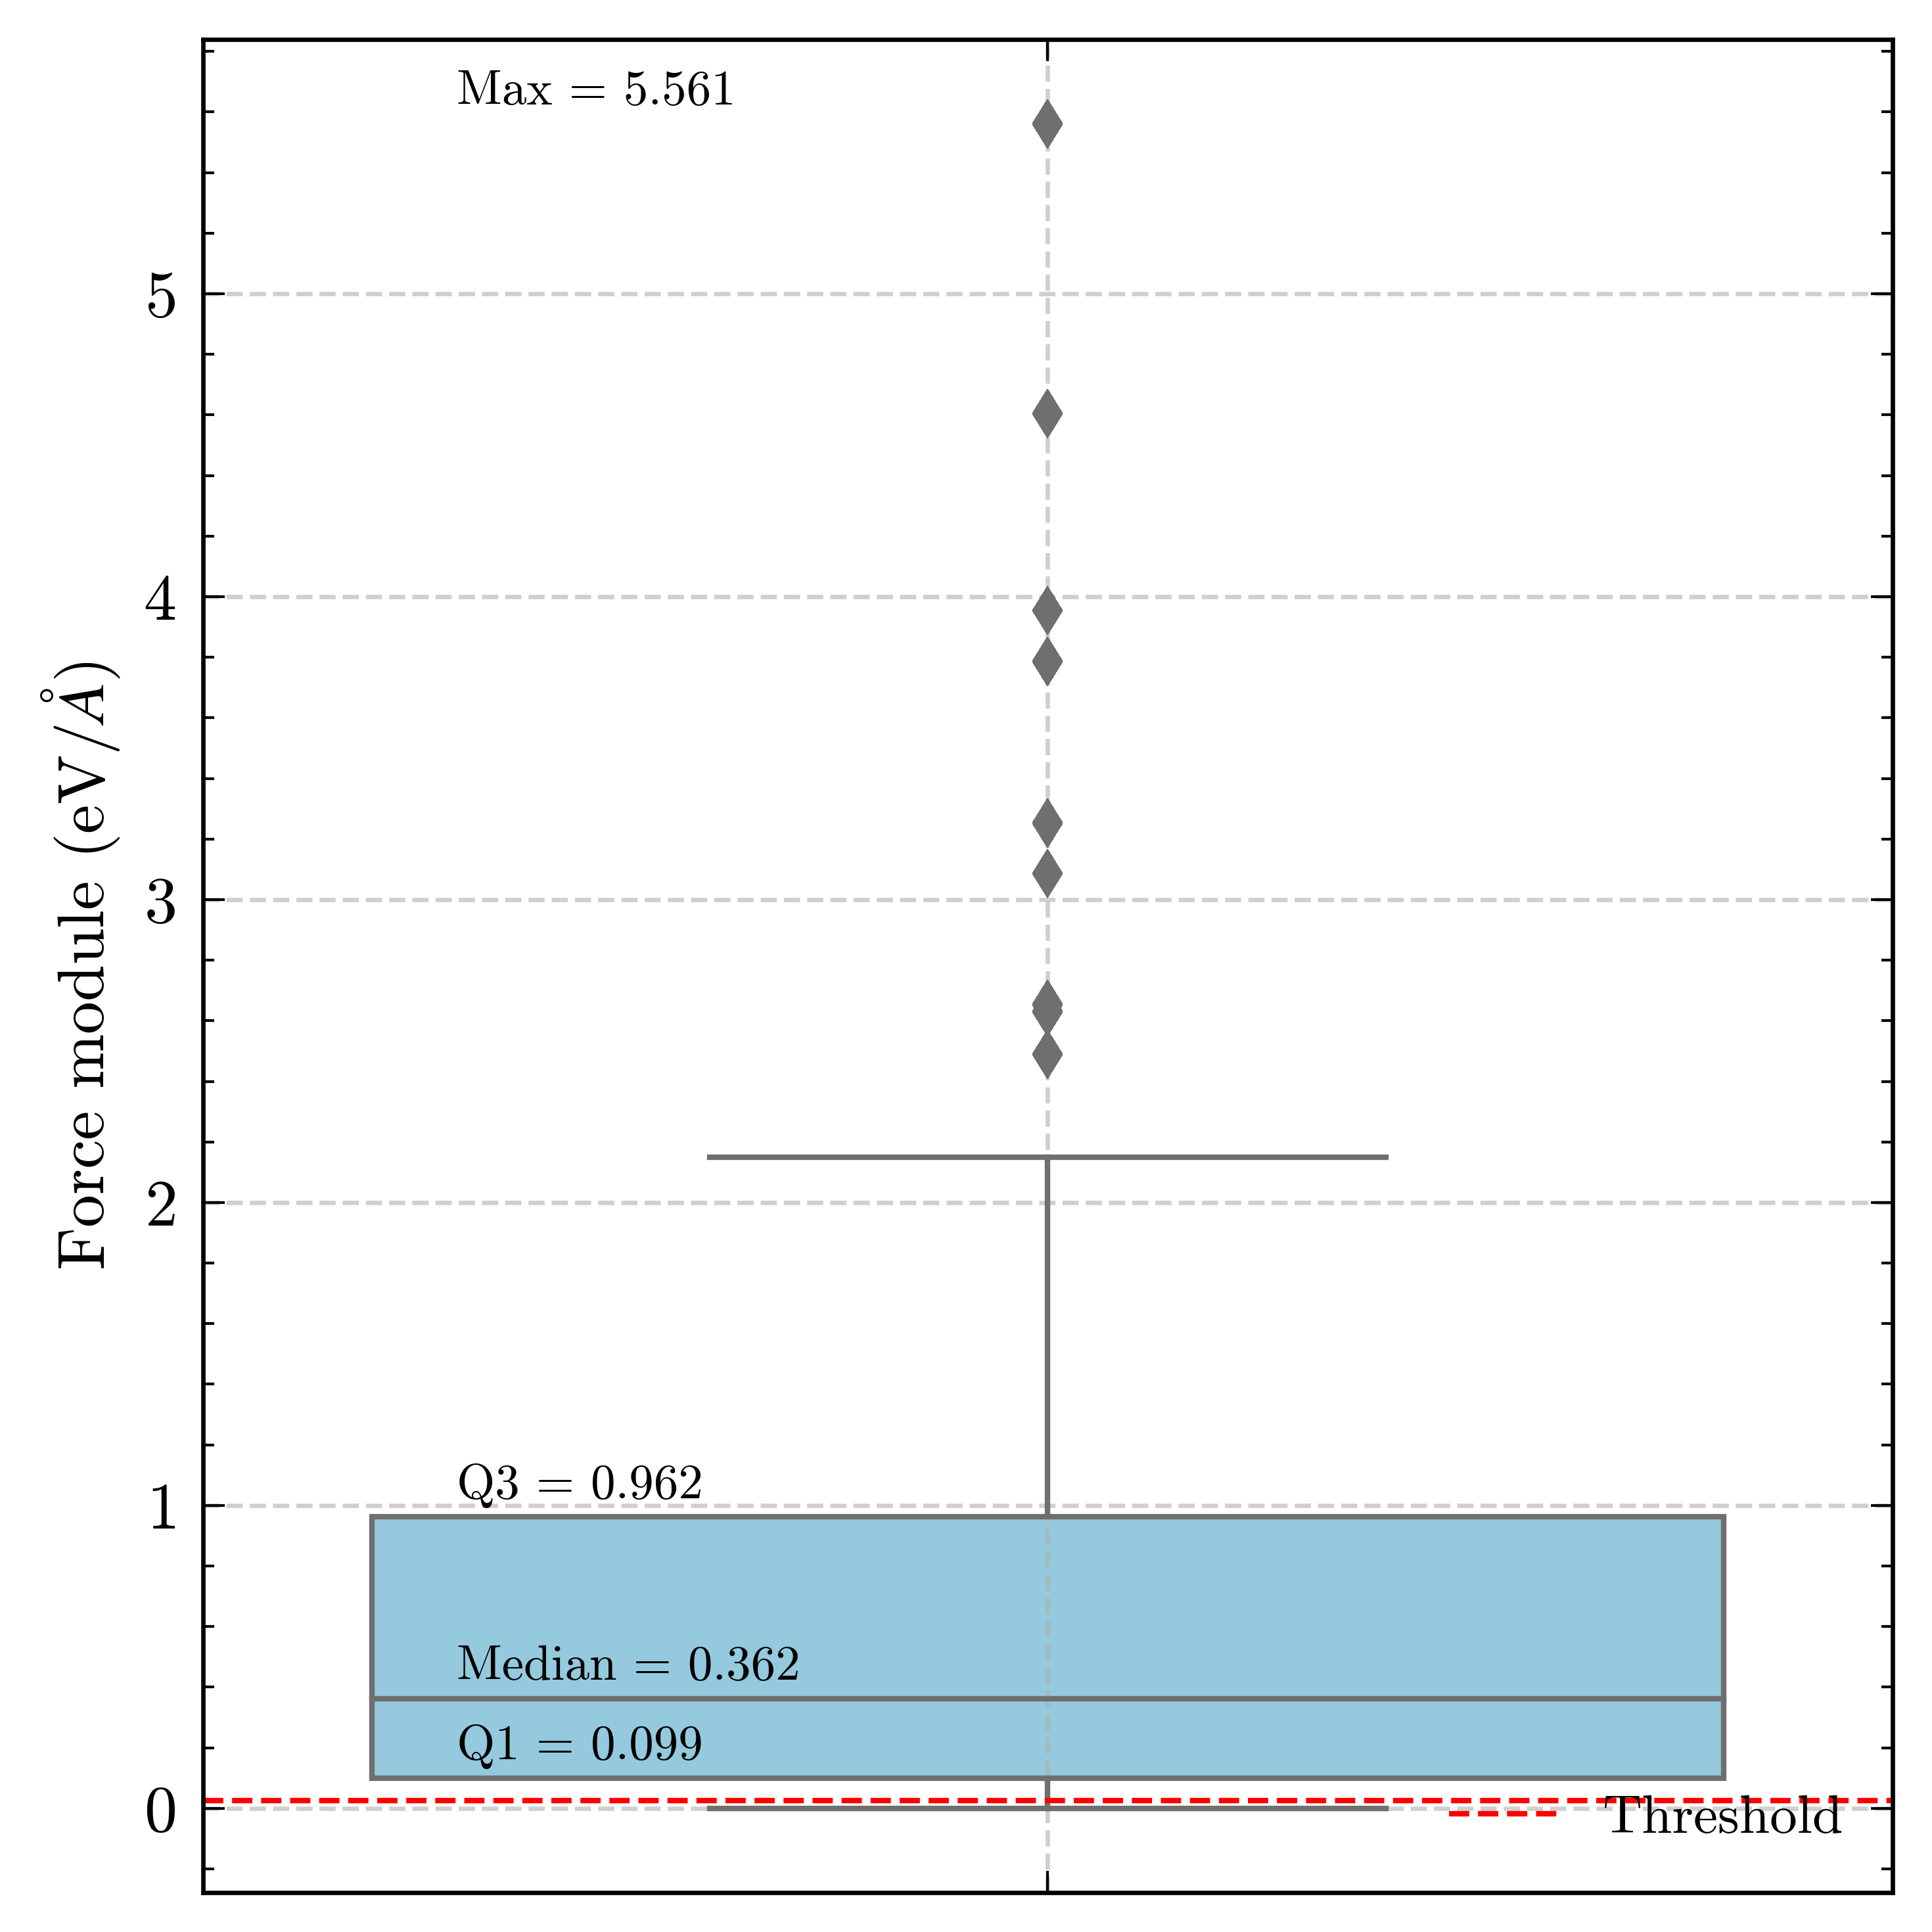

In [ ]:
# Values from describe()
q1 = db_atomo['modulo_eV_A'].quantile(0.25)
median = db_atomo['modulo_eV_A'].median()
q3 = db_atomo['modulo_eV_A'].quantile(0.75)
# minimum = db_atomo['modulo_eV_A'].min()
maximum = db_atomo['modulo_eV_A'].max()

# Threshold
conv_eV_A = 0.025711  # from earlier calculation

plt.figure(figsize=(5,5), dpi=600)
sns.boxplot(y=db_atomo['modulo_eV_A'], color="skyblue")

# Add threshold line with red text color
plt.axhline(conv_eV_A, color="red", linestyle="--", label=f"Threshold")


# Small vertical offset for annotations
offset = 0.03  

# Annotate quartiles and extremes (left side, slightly above value)
# plt.text(-0.35, minimum + offset, f"Min = {minimum:.3f}", va="bottom", ha="left", fontsize=9, color="black")
plt.text(-0.35, q1 + offset, f"Q1 = {q1:.3f}", va="bottom", ha="left", fontsize=9, color="black")
plt.text(-0.35, median + offset, f"Median = {median:.3f}", va="bottom", ha="left", fontsize=9, color="black")
plt.text(-0.35, q3 + offset, f"Q3 = {q3:.3f}", va="bottom", ha="left", fontsize=9, color="black")
plt.text(-0.35, maximum + offset, f"Max = {maximum:.3f}", va="bottom", ha="left", fontsize=9, color="black")

# Labels
plt.ylabel("Force module (eV/$\\AA$)")
# plt.title("Boxplot of Forces with Quantiles")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

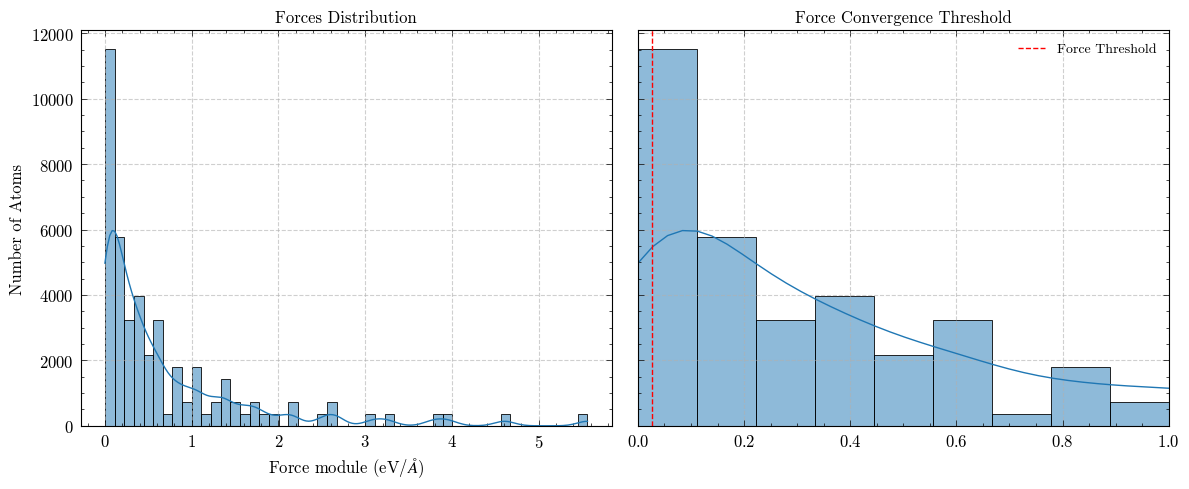

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12,5), sharey=True)
# geral
sns.histplot(db_atomo['modulo_eV_A'], kde=True, bins=50, ax=ax[0])
ax[0].set_title("Forces Distribution")
ax[0].set_xlabel("Force module (eV/$\AA$)")
ax[0].set_ylabel("Number of Atoms")
ax[0].grid(True, linestyle="--", alpha=0.6)

# zoom
ax[1].set_title("Force Convergence Threshold")
sns.histplot(db_atomo['modulo_eV_A'], kde=True, bins=50, ax=ax[1])
ax[1].axvline(conv_eV_A, color='red', ls='--', label="Force Threshold")
ax[1].set_xlim(0, 1)   # zoom até 2 eV/Å
ax[1].set_xlabel("")
ax[1].grid(True, linestyle="--", alpha=0.6)
ax[1].legend()
# plt.savefig('forces_dist.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

# Energia

In [ ]:
db_simulacao.columns

Index(['sim_id', 'supercelula', 'num_atomos', 'a', 'c', 'c/a',
       'energia_total_eV', 'Volume_A³', 'energia_total_Ry', 'Volume_(a.u)^3',
       'forcas_eV_Ang', 'forcas_Ry_Bohr'],
      dtype='object')

In [ ]:
dataset_energia = db_simulacao[['sim_id', 'supercelula', 'energia_total_eV', 'num_atomos','Volume_A³' ]].copy()
dataset_energia['energia_por_atomo_eV'] = dataset_energia['energia_total_eV'] / dataset_energia['num_atomos']
dataset_energia

,sim_id,supercelula,energia_total_eV,num_atomos,Volume_A³,energia_por_atomo_eV
0,ZnO-2.94-1.45-111,1x1x1,-4914.318818,4,32.064749,-1228.579705
1,ZnO-2.94-1.49-111,1x1x1,-4915.220202,4,32.777295,-1228.805051
2,ZnO-2.94-1.52-111,1x1x1,-4915.973006,4,33.489841,-1228.993252
3,ZnO-2.94-1.55-111,1x1x1,-4916.599402,4,34.202387,-1229.149850
4,ZnO-2.94-1.58-111,1x1x1,-4917.118557,4,34.914933,-1229.279639
...,...,...,...,...,...,...
2294,ZnO-3.60-1.65-331,3x3x1,-44270.535791,36,597.143099,-1229.737105
2295,ZnO-3.60-1.68-331,3x3x1,-44269.031624,36,608.851361,-1229.695323
2296,ZnO-3.60-1.71-331,3x3x1,-44267.479969,36,620.560710,-1229.652221
2297,ZnO-3.60-1.74-331,3x3x1,-44265.896994,36,632.268972,-1229.608250


In [ ]:
# dataset_energia.groupby('supercelula')['energia_por_atomo_eV'].mean().plot(kind='barh', color='cornflowerblue', figsize=(10,6))
# plt.show()

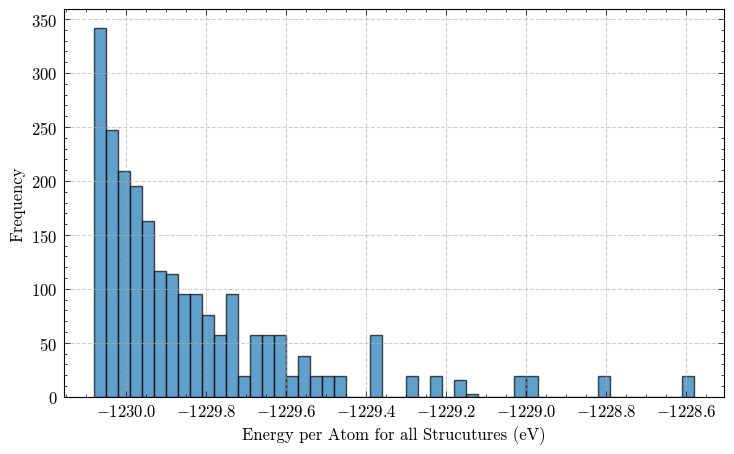

In [ ]:
with plt.style.context(scientific_theme_path):
    plt.figure(figsize=(8,5))
    plt.hist(dataset_energia["energia_por_atomo_eV"], bins=50, edgecolor="k", alpha=0.7)
    plt.xlabel("Energy per Atom for all Strucutures (eV)")
    plt.ylabel("Frequency")
    

    # Definir ticks "na mão"
   
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

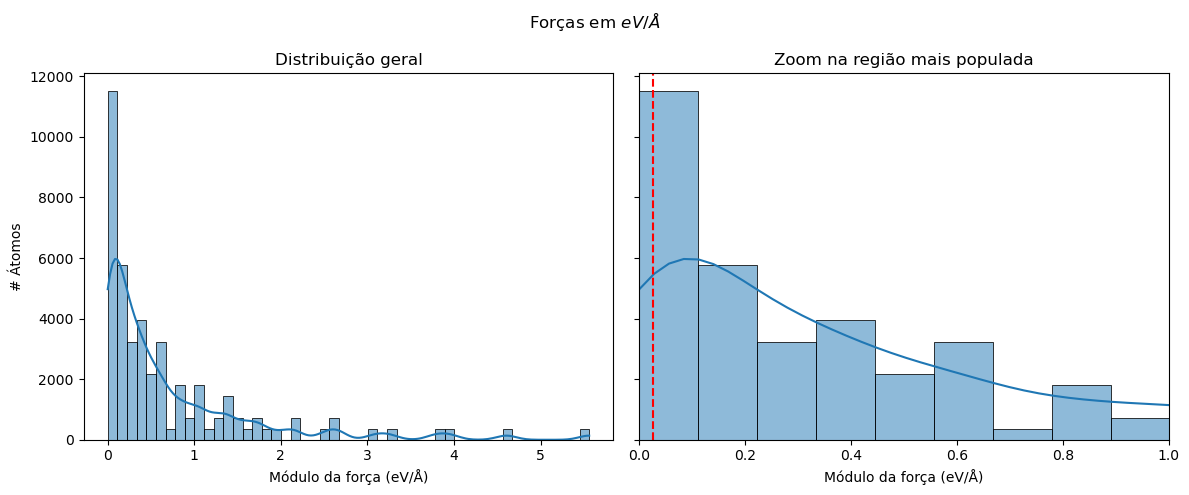

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12,5), sharey=True)
plt.suptitle(r"Forças em $eV/\AA$")
# geral
sns.histplot(db_atomo['modulo_eV_A'], kde=True, bins=50, ax=ax[0])
ax[0].set_title("Distribuição geral")
ax[0].set_xlabel("Módulo da força (eV/Å)")
ax[0].set_ylabel("# Átomos")

# zoom
sns.histplot(db_atomo['modulo_eV_A'], kde=True, bins=50, ax=ax[1])
ax[1].axvline(conv_eV_A, color='red', ls='--')
ax[1].set_xlim(0, 1)   # zoom até 2 eV/Å
ax[1].set_title("Zoom na região mais populada")
ax[1].set_xlabel("Módulo da força (eV/Å)")

plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import gaussian_kde
from scipy.integrate import quad

In [ ]:
# 1. Extraia os dados da força
forces = db_atomo['modulo_eV_A'].values

# 2. Crie a função de Estimativa de Densidade por Kernel (KDE)
kde = gaussian_kde(forces)

# 3. Integre a função KDE do critério de convergência até o infinito
#    A função quad retorna a integral e uma estimativa do erro. Pegamos apenas a integral [0].
area_nao_convergida, _ = quad(kde, conv_eV_A, np.inf)

# 4. (Opcional) Integre sobre todo o domínio para verificar se o total é ~1.0
area_total, _ = quad(kde, 0, np.inf)

# 5. Calcule a porcentagem
porcentagem_nao_convergida = (area_nao_convergida / area_total) * 100

print(f"Valor do critério de convergência: {conv_eV_A:.4f} eV/Å")
print("-" * 50)
print("Resultados da Integração da Curva KDE:")
print(f"\tÁrea total sob a curva (deveria ser ~1.0): {area_total:.4f}")
print(f"\tÁrea acima do critério de convergência: {area_nao_convergida:.4f}")
print(f"\tPorcentagem de átomos com força > critério: {porcentagem_nao_convergida:.2f}%")

Valor do critério de convergência: 0.0257 eV/Å
--------------------------------------------------
Resultados da Integração da Curva KDE:
	Área total sob a curva (deveria ser ~1.0): 0.8862
	Área acima do critério de convergência: 0.8585
	Porcentagem de átomos com força > critério: 96.88%


In [ ]:
(db_atomo['modulo_eV_A'] > conv_eV_A).sum() / db_atomo['modulo_eV_A'].size


0.8925619834710744

In [ ]:
print(f"{units.Bohr = }, {units.Ry = }`") # 1 raio de Bohr em Angstrom , 1 Ry em eV
print(f"{units.Ry / units.Bohr = }") # eV/A

units.Bohr = 0.5291772105638411, units.Ry = 13.605693012183622`
units.Ry / units.Bohr = 25.711033545240323


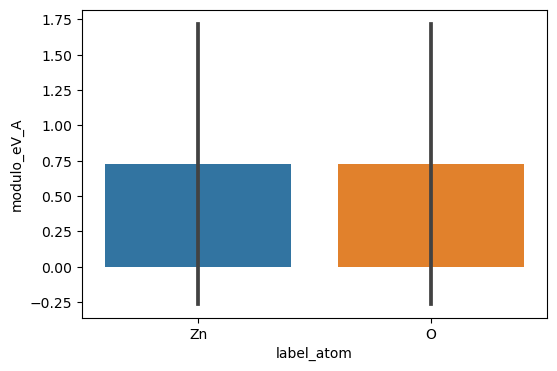

In [ ]:
plt.figure(
    figsize=(6,4)
)
sns.barplot(x="label_atom", y='modulo_eV_A', data=db_atomo, estimator='mean', errorbar='sd')



plt.show()

In [ ]:
db_atomo.groupby("label_atom")["modulo_eV_A"].mean()

label_atom
O     0.729972
Zn    0.729973
Name: modulo_eV_A, dtype: float64

0.7299726002908735

In [ ]:
db_atomo[
    db_atomo['label_atom'] == 'O'
]['modulo_eV_A'].mean()

0.7299717540266127

8.462642607787174e-07


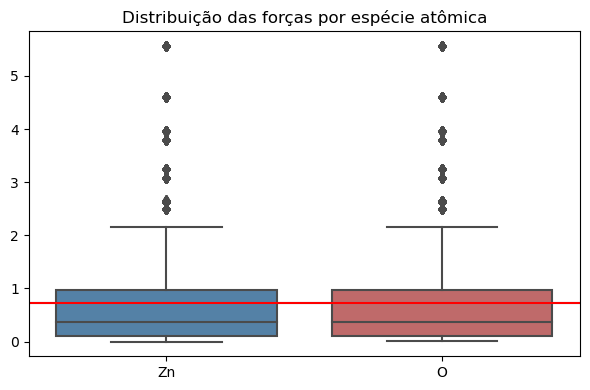

In [ ]:
plt.figure(figsize=(6,4))
ax = sns.boxplot(x="label_atom", y="modulo_eV_A", 
    data=db_atomo,
    palette={"Zn": "steelblue", "O": "indianred"},
    meanline=True

)

media_Zn = db_atomo[db_atomo['label_atom'] == 'Zn']['modulo_eV_A'].mean()
media_O = db_atomo[db_atomo['label_atom'] == 'O']['modulo_eV_A'].mean()

ax.axhline(media_Zn, color='#09c6fc')
ax.axhline(media_O, color='red')
plt.xlabel("")
plt.ylabel("")
plt.title("Distribuição das forças por espécie atômica")
plt.tight_layout()
plt.show()


#  
<h1 style="
    background-color: #251351; 
    color: white; 
    padding: 10px; 
    text-align: left; 
    font-family: Arial, sans-serif; 
    font-size: 32px; 
    font-weight: bold; 
    margin: 10px 0;">
    Distribuição de Energias
</h1>  

-  Escolha do dataset wide (simulação-simulação)
- Curvas de Energia vs Volume
- Mapa $(a, c/a) \rightarrow E_{tot}$ 



In [ ]:
db_simulacao.head()

,sim_id,supercelula,num_atomos,a,c,c/a,energia_total_eV,Volume_A³,energia_total_Ry,Volume_(a.u)^3,forcas_eV_Ang,forcas_Ry_Bohr
0,ZnO-2.94-1.45-111,1x1x1,4,2.942738,4.275572,1.452923,-4914.318818,32.064749,-361.195774,216.383651,[[-0. -0. -5.55985169]\n [ 0. ...,[[-0. -0. -0.2162438]\n [ 0. ...
1,ZnO-2.94-1.49-111,1x1x1,4,2.942738,4.370584,1.485210,-4915.220202,32.777295,-361.262024,221.192150,[[-0. -0. -3.95390595]\n [ 0. ...,[[-0. -0. -0.15378246]\n [ 0. ...
2,ZnO-2.94-1.52-111,1x1x1,4,2.942738,4.465596,1.517497,-4915.973006,33.489841,-361.317355,226.000649,[[ 0. 0. -2.62872698]\n [ 0. ...,[[ 0. 0. -0.1022412]\n [ 0. ...
3,ZnO-2.94-1.55-111,1x1x1,4,2.942738,4.560608,1.549784,-4916.599402,34.202387,-361.363394,230.809149,[[ 0. 0. -1.54398653]\n [ 0. ...,[[ 0. 0. -0.06005152]\n [ 0. ...
4,ZnO-2.94-1.58-111,1x1x1,4,2.942738,4.655621,1.582071,-4917.118557,34.914933,-361.401551,235.617648,[[-0. -0. -0.66267176]\n [ 0. ...,[[-0. -0. -0.02577383]\n [ 0. ...


In [ ]:
df_energia_atomos = db_simulacao[['sim_id','supercelula','num_atomos','energia_total_eV']].copy()
df_energia_atomos['energia_per_atomo'] = abs(df_energia_atomos['energia_total_eV'] / df_energia_atomos['num_atomos'])
df_energia_atomos

,sim_id,supercelula,num_atomos,energia_total_eV,energia_per_atomo
0,ZnO-2.94-1.45-111,1x1x1,4,-4914.318818,1228.579705
1,ZnO-2.94-1.49-111,1x1x1,4,-4915.220202,1228.805051
2,ZnO-2.94-1.52-111,1x1x1,4,-4915.973006,1228.993252
3,ZnO-2.94-1.55-111,1x1x1,4,-4916.599402,1229.149850
4,ZnO-2.94-1.58-111,1x1x1,4,-4917.118557,1229.279639
...,...,...,...,...,...
2294,ZnO-3.60-1.65-331,3x3x1,36,-44270.535791,1229.737105
2295,ZnO-3.60-1.68-331,3x3x1,36,-44269.031624,1229.695323
2296,ZnO-3.60-1.71-331,3x3x1,36,-44267.479969,1229.652221
2297,ZnO-3.60-1.74-331,3x3x1,36,-44265.896994,1229.608250


In [ ]:
df_energia_atomos.groupby("supercelula")[['energia_per_atomo']].mean()

,energia_per_atomo
supercelula,
1x1x1,1229.835720
1x1x2,1229.835758
1x1x3,1229.835757
1x2x1,1229.836030
1x2x2,1229.836049
1x2x3,1229.836049
1x3x1,1229.836045
1x3x2,1229.836062
2x1x1,1229.836030


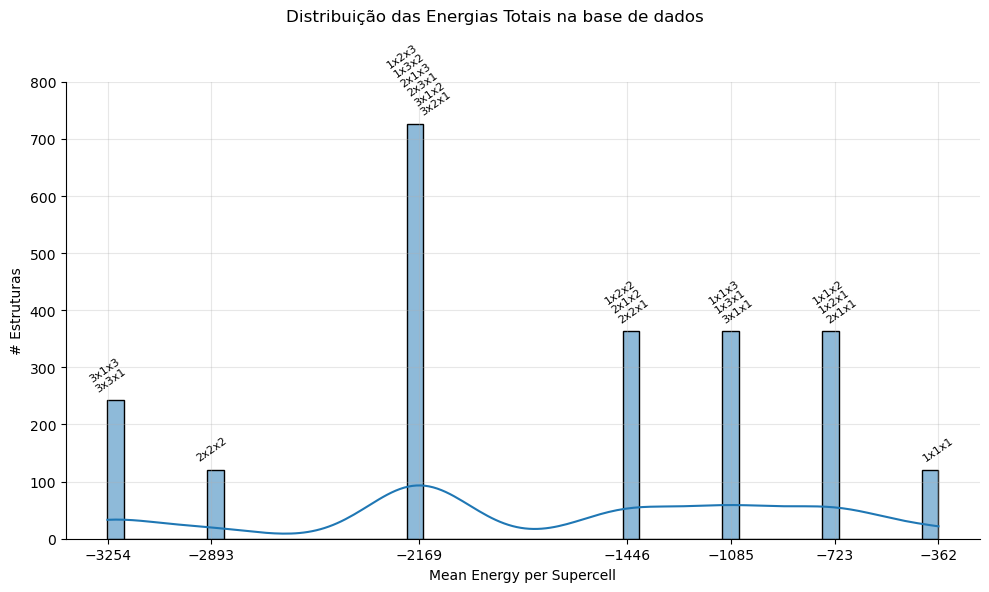

In [ ]:
plt.figure(figsize=(10, 6))
plt.suptitle("Distribuição das Energias Totais na base de dados")

ax = sns.histplot(db_wide['energia_total_Ry'], kde=True, bins=50)
plt.xlabel("Mean Energy per Supercell")
plt.ylabel("# Estruturas")
sns.despine(top=True, right=True, ax=ax)

# Definindo os picos
pico1 = db_wide['energia_total_Ry'] < - 3000
pico2 = (db_wide['energia_total_Ry'] < - 2500) & (db_wide['energia_total_Ry'] > - 3000)
pico3 = (db_wide['energia_total_Ry'] > - 2500) & (db_wide['energia_total_Ry'] < - 2000)
pico4 = (db_wide['energia_total_Ry'] > - 1500) & (db_wide['energia_total_Ry'] < - 1250)
pico5 = (db_wide['energia_total_Ry'] > - 1300) & (db_wide['energia_total_Ry'] < - 1000)
pico6 = (db_wide['energia_total_Ry'] > - 1000) & (db_wide['energia_total_Ry'] < - 500)
pico7 = (db_wide['energia_total_Ry'] > - 500)
picos_energia = [pico1, pico2, pico3, pico4, pico5, pico6, pico7]

mean_energys = []
ax.set_ylim(top=800)

for pico in picos_energia:
    supercelulas: list[str] = db_wide[pico].supercelula.unique()
    num_estruturas: int = db_wide[pico].shape[0]
    energia_media = db_wide[pico].energia_total_Ry.mean()
    
    # Formatando lista de supercélulas em várias linhas
    label_text = "\n".join(supercelulas)
    
    # Anotar supercélulas deslocadas um pouco para cima
    ax.annotate(
        text=label_text,
        xy=(energia_media, num_estruturas),
        xytext=(0, 5),  # desloca texto para cima
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=35
        #arrowprops=dict(arrowstyle="->", lw=0.5)
    )
    
    mean_energys.append(energia_media)

ax.set_xticks(mean_energys)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

In [ ]:
db_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43560 entries, 0 to 43559
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sim_id            43560 non-null  object 
 1   supercelula       43560 non-null  object 
 2   num_atomos        43560 non-null  int64  
 3   atom_id           43560 non-null  object 
 4   atom_type         43560 non-null  int64  
 5   energia_total_eV  43560 non-null  float64
 6   Volume_A³         43560 non-null  float64
 7   energia_total_Ry  43560 non-null  float64
 8   Volume_(a.u)^3    43560 non-null  float64
 9   fx_Ry_bohr        43560 non-null  float64
 10  fy_Ry_bohr        43560 non-null  float64
 11  fz_Ry_bohr        43560 non-null  float64
 12  modulo_Ry_bohr    43560 non-null  float64
 13  modulo_eV_A       43560 non-null  float64
 14  label_atom        43560 non-null  object 
dtypes: float64(9), int64(2), object(4)
memory usage: 5.0+ MB


---

# Energy vs Volume

/tmp/ipykernel_1017429/2745845907.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.cm.get_cmap('tab20', len(supercells_type))


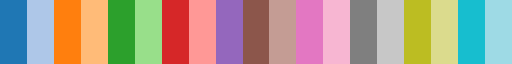

In [ ]:
plt.cm.get_cmap('tab20', len(supercells_type))

In [ ]:
len(list_df_sc)

19

In [38]:
db_energia = db_simulacao[['sim_id','num_atomos' ,'supercelula', 'a', 'c/a', 'energia_total_eV', 'Volume_A³']].copy()

db_energia['E/atom'] = db_energia['energia_total_eV'] / db_energia['num_atomos']
db_energia['V/atom'] = db_energia['Volume_A³'] / db_energia['num_atomos']

db_energia
list_df_sc: list[pd.DataFrame] = []

supercells_type: list[str] = db_energia['supercelula'].unique()

In [33]:
db_energia

,sim_id,num_atomos,supercelula,a,c/a,energia_total_eV,Volume_A³,E/atom,V/atom
0,ZnO-2.94-1.45-111,4,1x1x1,2.942738,1.452923,-4914.318818,32.064749,-1228.579705,8.016187
1,ZnO-2.94-1.49-111,4,1x1x1,2.942738,1.485210,-4915.220202,32.777295,-1228.805051,8.194324
2,ZnO-2.94-1.52-111,4,1x1x1,2.942738,1.517497,-4915.973006,33.489841,-1228.993252,8.372460
3,ZnO-2.94-1.55-111,4,1x1x1,2.942738,1.549784,-4916.599402,34.202387,-1229.149850,8.550597
4,ZnO-2.94-1.58-111,4,1x1x1,2.942738,1.582071,-4917.118557,34.914933,-1229.279639,8.728733
...,...,...,...,...,...,...,...,...,...
2294,ZnO-3.60-1.65-331,36,3x3x1,10.790039,0.548882,-44270.535791,597.143099,-1229.737105,16.587308
2295,ZnO-3.60-1.68-331,36,3x3x1,10.790039,0.559644,-44269.031624,608.851361,-1229.695323,16.912538
2296,ZnO-3.60-1.71-331,36,3x3x1,10.790039,0.570407,-44267.479969,620.560710,-1229.652221,17.237798
2297,ZnO-3.60-1.74-331,36,3x3x1,10.790039,0.581169,-44265.896994,632.268972,-1229.608250,17.563027


In [124]:
celula111 = db_energia.query("supercelula == '1x1x1'").copy()
celula111.head()

,sim_id,num_atomos,supercelula,a,c/a,energia_total_eV,Volume_A³,E/atom,V/atom
0,ZnO-2.94-1.45-111,4,1x1x1,2.942738,1.452923,-4914.318818,32.064749,-1228.579705,8.016187
1,ZnO-2.94-1.49-111,4,1x1x1,2.942738,1.485210,-4915.220202,32.777295,-1228.805051,8.194324
2,ZnO-2.94-1.52-111,4,1x1x1,2.942738,1.517497,-4915.973006,33.489841,-1228.993252,8.372460
3,ZnO-2.94-1.55-111,4,1x1x1,2.942738,1.549784,-4916.599402,34.202387,-1229.149850,8.550597
4,ZnO-2.94-1.58-111,4,1x1x1,2.942738,1.582071,-4917.118557,34.914933,-1229.279639,8.728733


Minimum energy point: c/a=1.61
V=48.87 Å³
E=-4920.32 eV


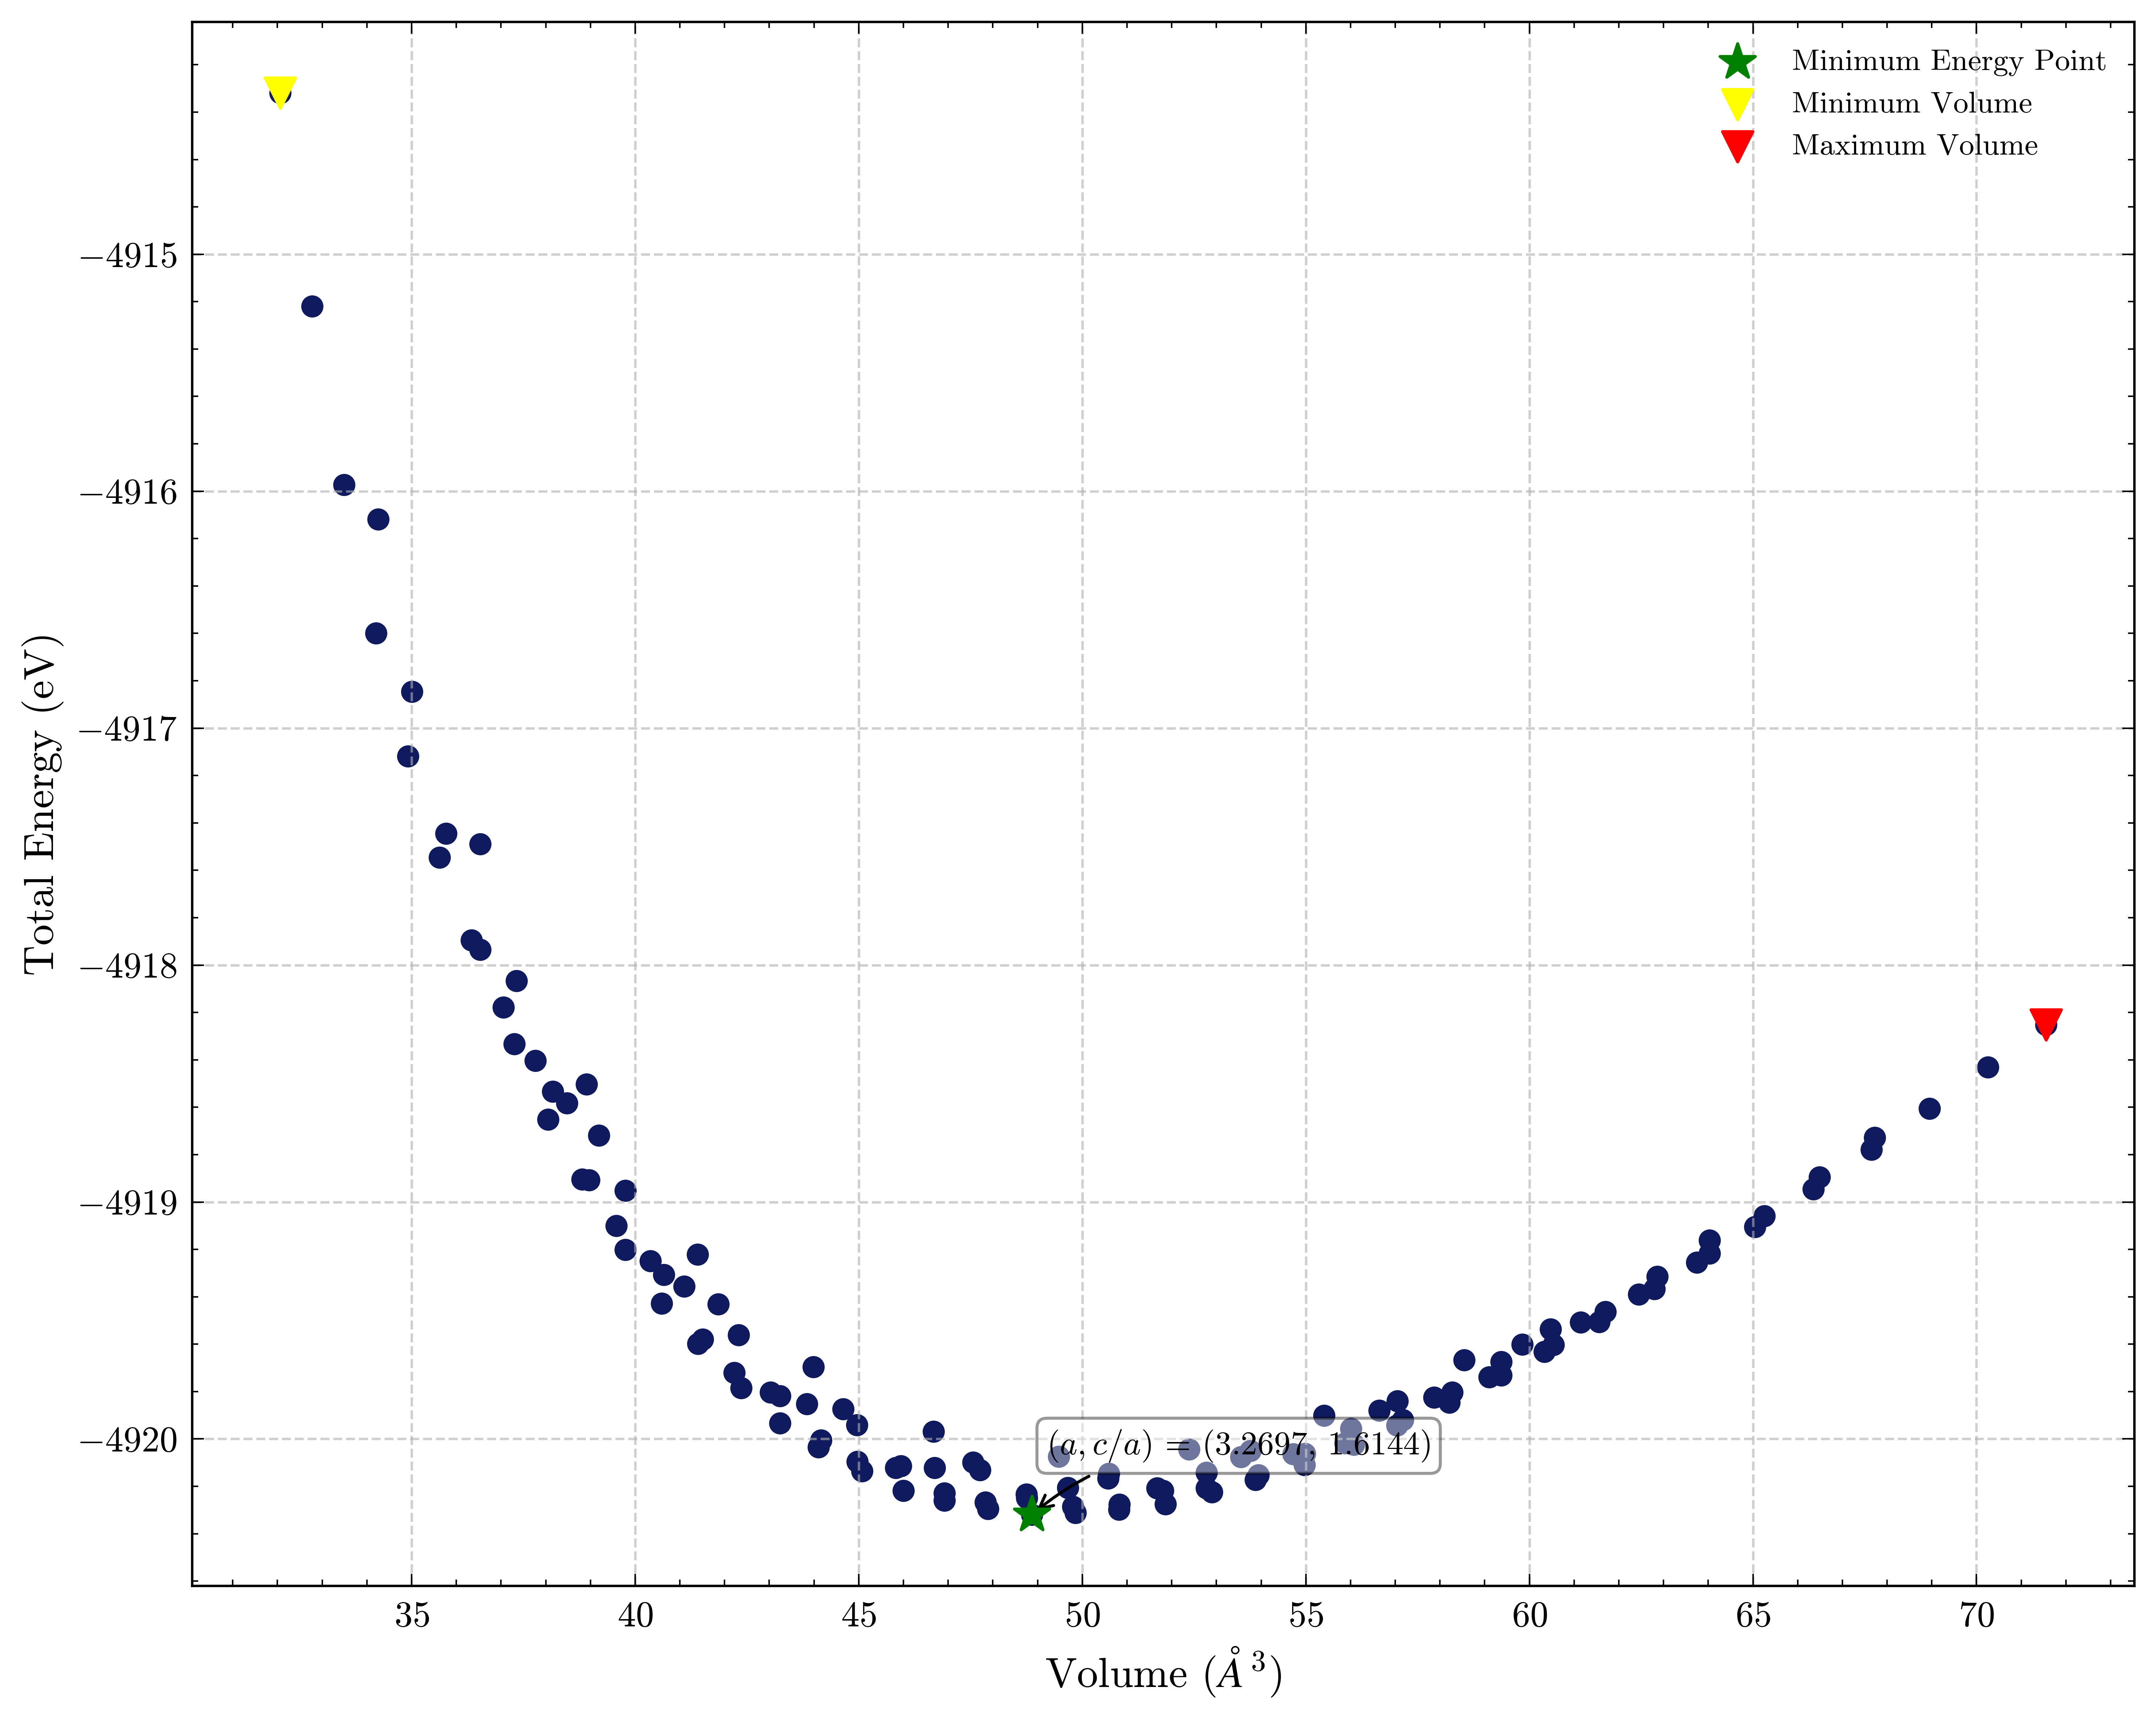

In [163]:
min_energy_idx = celula111['energia_total_eV'].idxmin()
min_energy_point = celula111.loc[min_energy_idx]
print(f"Minimum energy point: c/a={min_energy_point['c/a']:.2f}\nV={min_energy_point['Volume_A³']:.2f} Å³\nE={min_energy_point['energia_total_eV']:.2f} eV")



plt.figure(figsize=(10, 8), dpi=600)
plt.ylabel('Total Energy (eV)', fontsize=14)
plt.xlabel('Volume ($\AA^3$)', fontsize=14)

plt.scatter(celula111['Volume_A³'], celula111['energia_total_eV'], s=40, color="#0f1b5e")

# Plotando o ponto de energia mínima
plt.scatter(min_energy_point['Volume_A³'], min_energy_point['energia_total_eV'], 
            color='green', s=150, label='Minimum Energy Point', zorder=5, marker='*')

# Anotar o ponto de menor energia com os valores (a, c/a)
plt.annotate(f'$(a, c/a)$ = ({min_energy_point["a"]:.4f}, {min_energy_point["c/a"]:.4f})', 
            xy=(min_energy_point['Volume_A³'], min_energy_point['energia_total_eV']),
            xytext=(5, 20), textcoords='offset points',
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.4),
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.2"))

# Marcar os extremos
plt.scatter(
    x=celula111['Volume_A³'].min(),
    y=celula111['energia_total_eV'].max(),
    color='yellow',
    marker='v',
    s=100,
    label='Minimum Volume',
)
# Marcar os extremos
plt.scatter(
    x=celula111['Volume_A³'].max(),
    y=celula111.loc[celula111['Volume_A³'].idxmax(), 'energia_total_eV'],
    color='red',
    marker='v',
    s=100,
    label='Maximum Volume',
)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig('energy_volume_1x1x1.png', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()

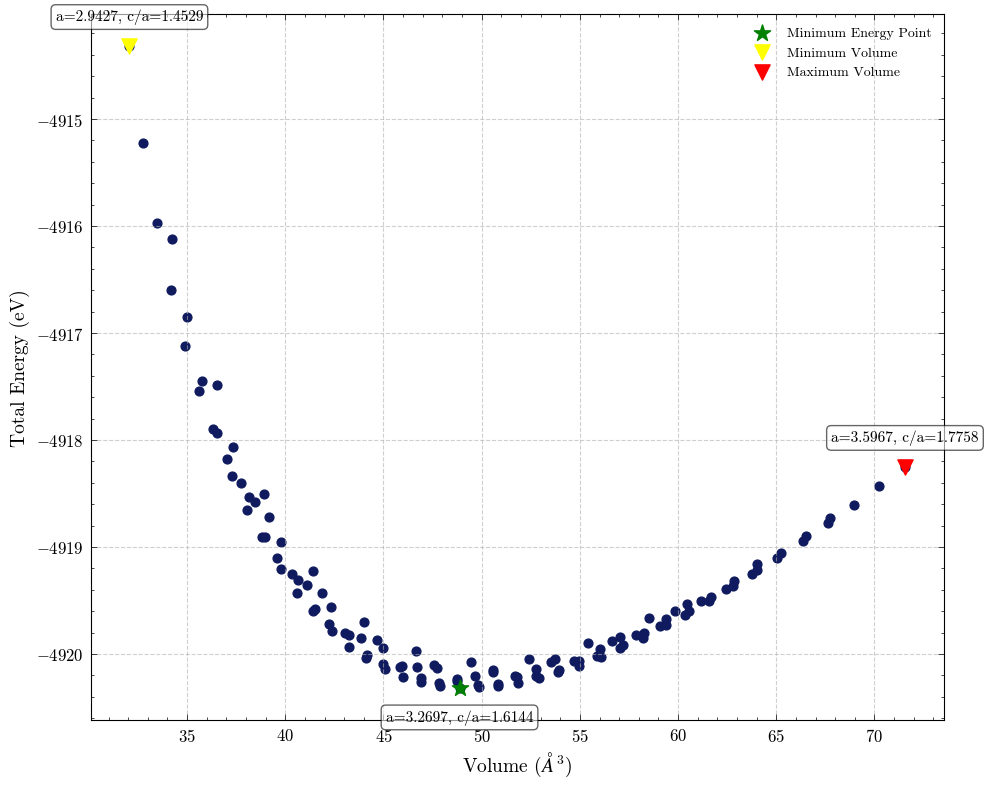

In [159]:
# Índices dos pontos de interesse
min_energy_idx = celula111['energia_total_eV'].idxmin()
min_vol_idx = celula111['Volume_A³'].idxmin()
max_vol_idx = celula111['Volume_A³'].idxmax()

# Seleciona os pontos
min_energy_point = celula111.loc[min_energy_idx]
min_vol_point = celula111.loc[min_vol_idx]
max_vol_point = celula111.loc[max_vol_idx]

plt.figure(figsize=(10, 8))
plt.ylabel('Total Energy (eV)', fontsize=14)
plt.xlabel('Volume ($\AA^3$)', fontsize=14)

plt.scatter(celula111['Volume_A³'], celula111['energia_total_eV'], s=40, color="#0f1b5e")

# Marcar pontos
plt.scatter(min_energy_point['Volume_A³'], min_energy_point['energia_total_eV'],
            color='green', s=150, label='Minimum Energy Point', marker='*', zorder=5)
plt.scatter(min_vol_point['Volume_A³'], min_vol_point['energia_total_eV'],
            color='yellow', s=120, label='Minimum Volume', marker='v', zorder=5)
plt.scatter(max_vol_point['Volume_A³'], max_vol_point['energia_total_eV'],
            color='red', s=120, label='Maximum Volume', marker='v', zorder=5)

# Anotações textuais
bbox_dict = dict(facecolor='white', alpha=0.6, boxstyle="round,pad=0.3")
plt.text(min_energy_point['Volume_A³'], 
         min_energy_point['energia_total_eV'] - 0.2,
         f"a={min_energy_point['a']:.4f}, c/a={min_energy_point['c/a']:.4f}",
         fontsize=11, ha='center', va='top', bbox=bbox_dict
)

plt.text(min_vol_point['Volume_A³'],
         min_vol_point['energia_total_eV'] + 0.2,
         f"a={min_vol_point['a']:.4f}, c/a={min_vol_point['c/a']:.4f}",
         fontsize=11, ha='center', va='bottom', bbox=bbox_dict
)

plt.text(max_vol_point['Volume_A³'], 
         max_vol_point['energia_total_eV'] + 0.2,
         f"a={max_vol_point['a']:.4f}, c/a={max_vol_point['c/a']:.4f}",
         fontsize=11, ha='center', va='bottom', bbox=bbox_dict
)

plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


Therefore, when you normalize the total energy by the number of atoms, you should get the same value for all of them. The fact that their E-V curves are superimposed demonstrates that your calculations are converging to the correct bulk energy per atom for a 12-atom system.

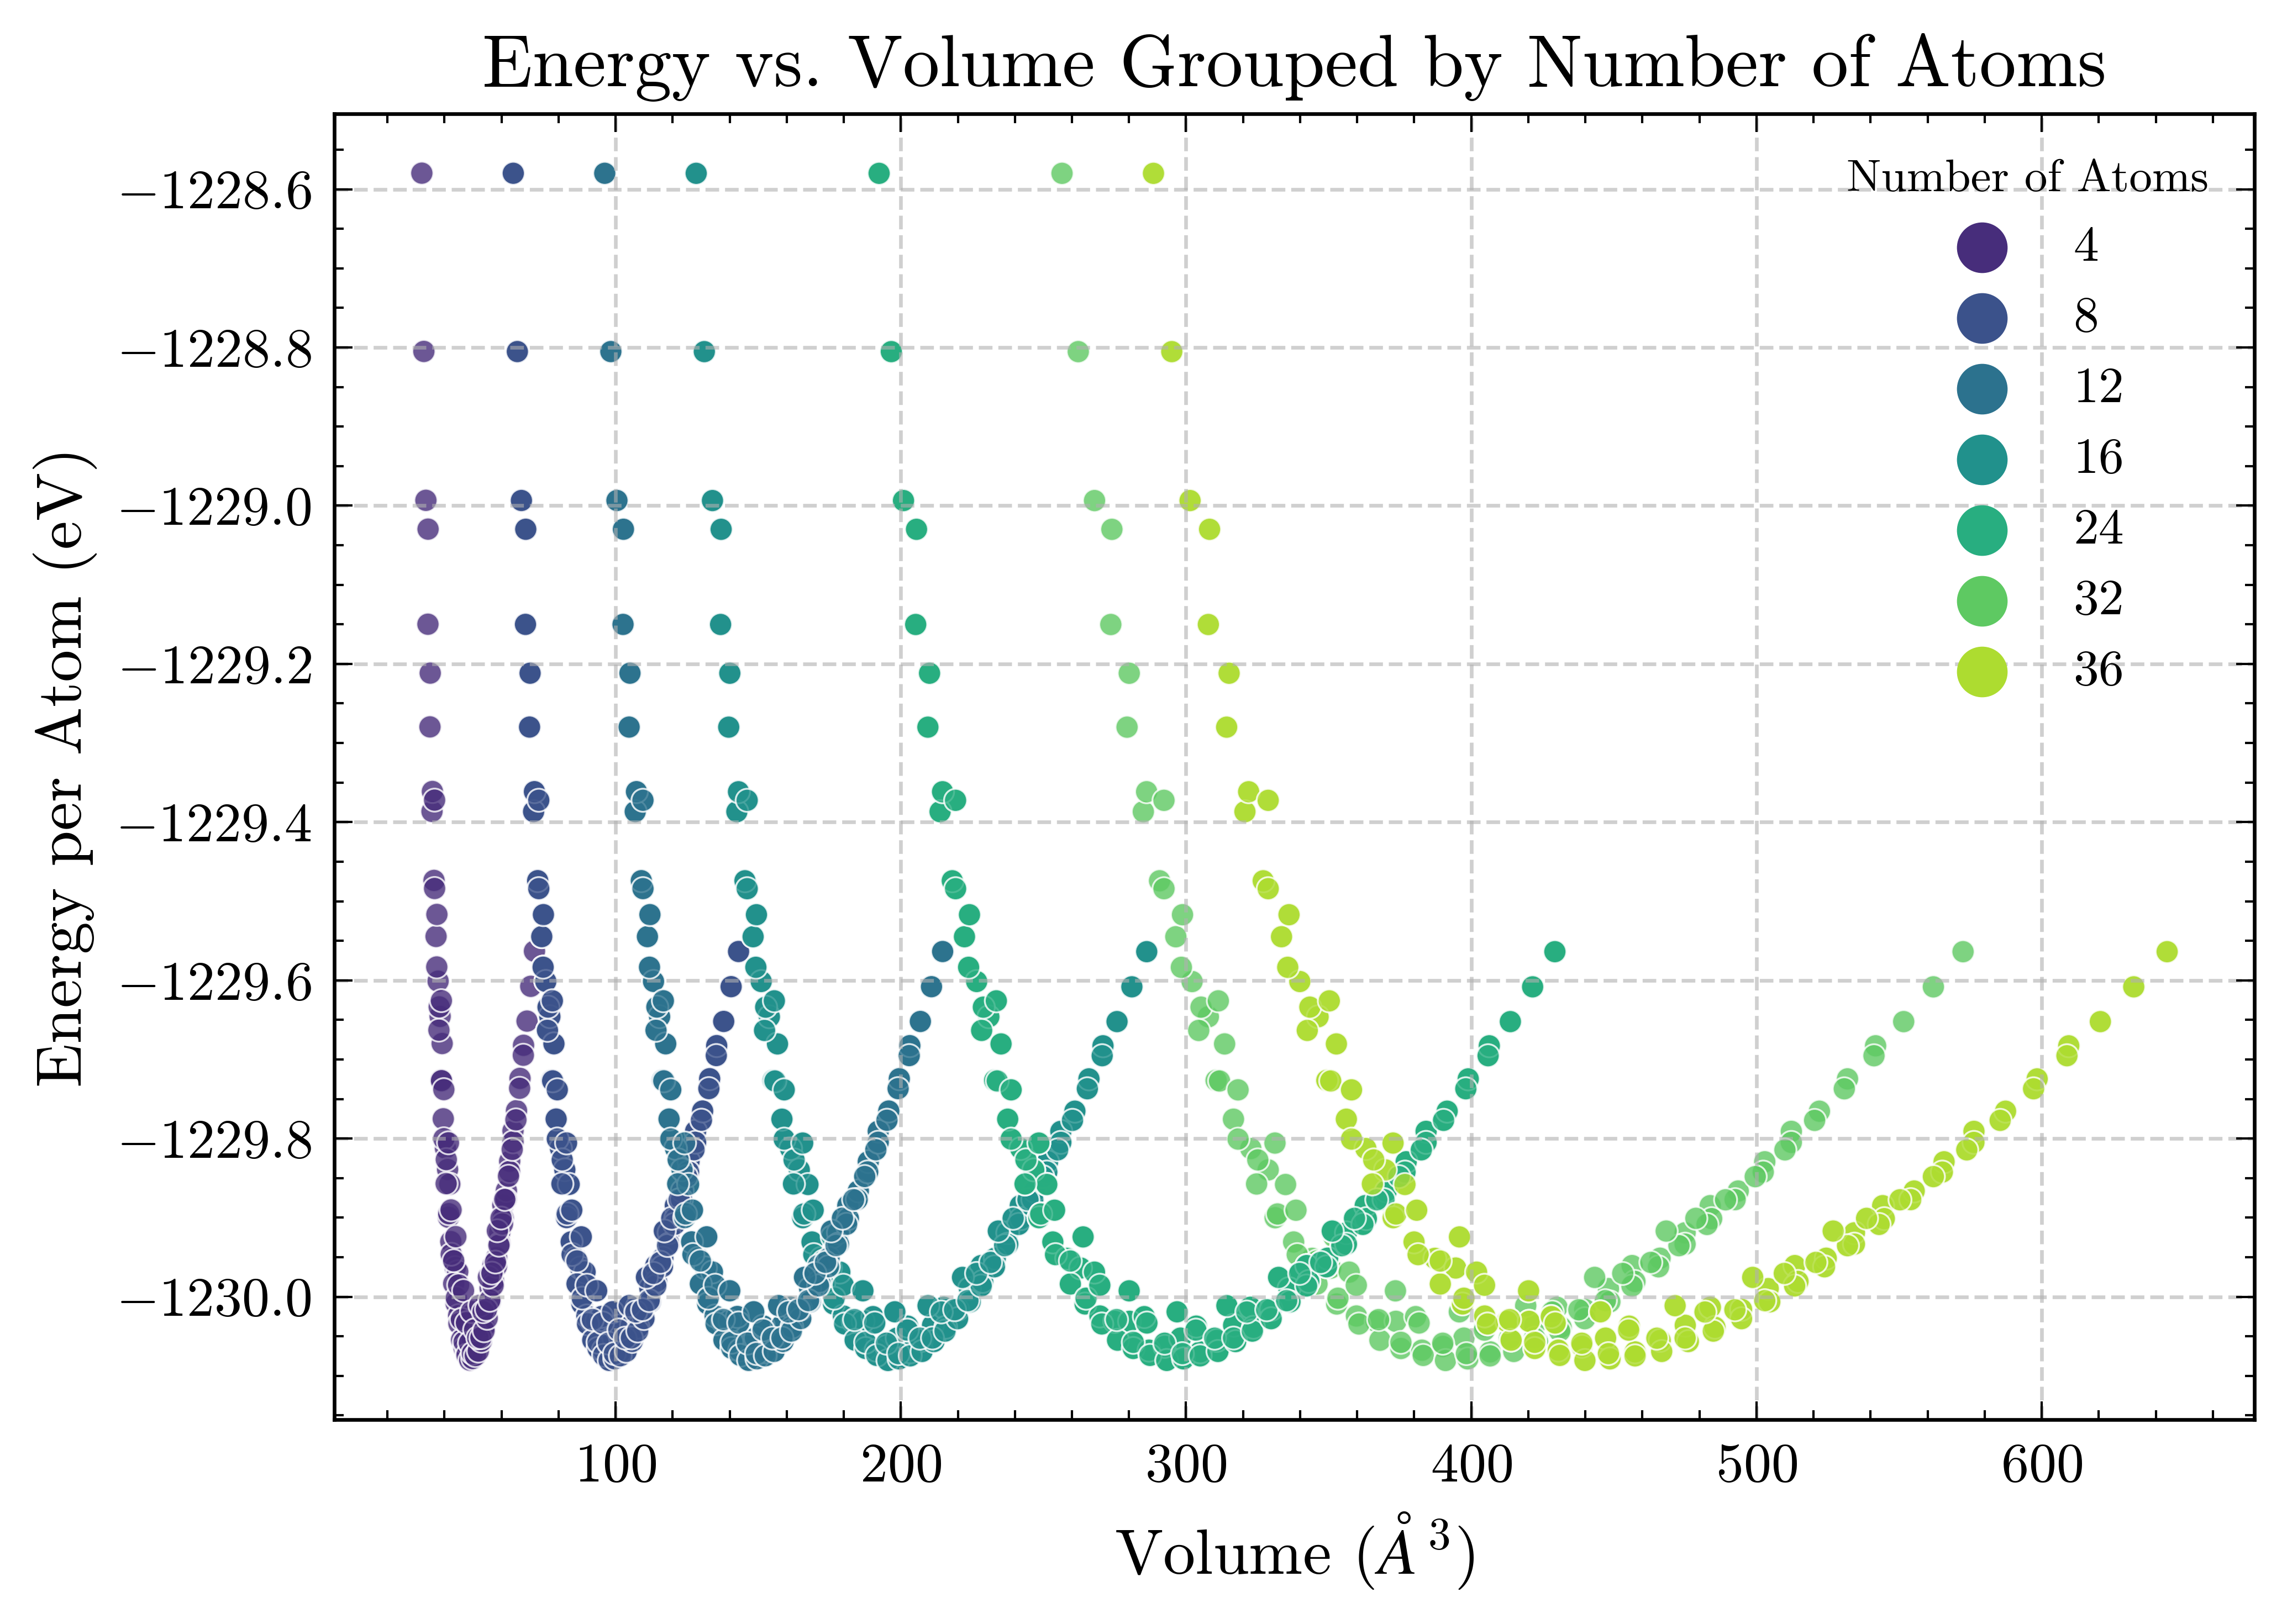

In [ ]:

# Assuming 'db_energia' is your prepared DataFrame
# ... ensure it has the 'E/atom' and 'num_atomos' columns

# For a clearer legend, it's good to treat the number of atoms as a category
db_energia['num_atomos_cat'] = db_energia['num_atomos'].astype(str)

fig, ax = plt.subplots(figsize=(7, 5), dpi=600)

sns.scatterplot(
    data=db_energia,
    x='Volume_A³',
    y='E/atom',
    hue='num_atomos_cat', # <-- The key change is here!
    palette='viridis', # A good colormap for ordered data
    s=25,
    alpha=0.8,
    ax=ax
)

ax.set_xlabel('Volume ($\AA^3$)', fontsize=14)
ax.set_ylabel('Energy per Atom (eV)', fontsize=14)
ax.set_title('Energy vs. Volume Grouped by Number of Atoms', fontsize=16)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title='Number of Atoms', fontsize=11)

plt.tight_layout()
plt.show()

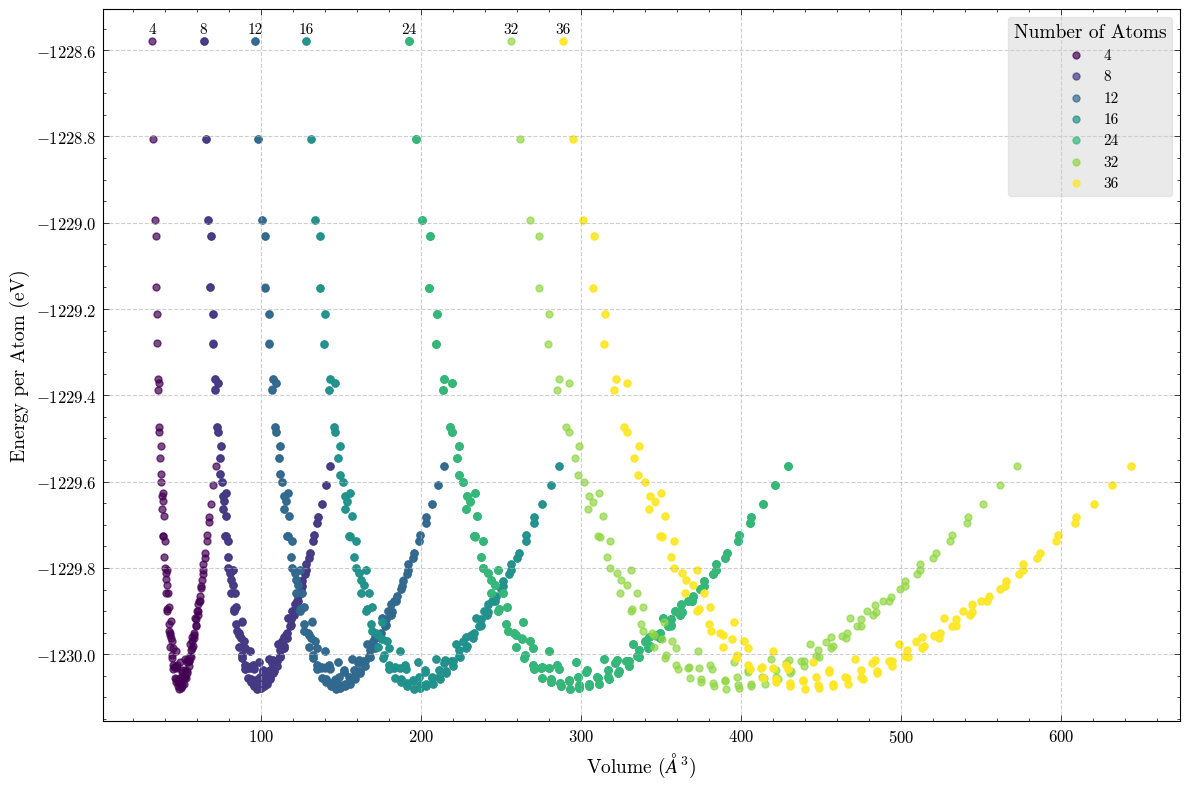

In [ ]:
# Assuming 'db_energia' is your prepared DataFrame with 'E/atom' and 'num_atomos'
# and the 'supercelula' column has been cleaned with .str.strip()

# --- Plotting Code with Annotations ---

fig, ax = plt.subplots(figsize=(12, 8))

# Get the unique atom counts to loop through
unique_atom_counts = sorted(db_energia['num_atomos'].unique())

# Generate a unique color for each group from a colormap
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_atom_counts)))

# Loop through each group of atoms
for i, num_atoms in enumerate(unique_atom_counts):
    # Create a subset of the data for the current group
    df_group = db_energia[db_energia['num_atomos'] == num_atoms]

    # Plot the scatter points for this group
    ax.scatter(
        x=df_group['Volume_A³'],
        y=df_group['E/atom'],
        color=colors[i],
        label=str(num_atoms),
        s=25,
        alpha=0.7
    )

    # --- Annotation Logic ---
    # Find the point with the lowest volume in the current group
    min_volume = df_group['Volume_A³'].min()
    points_at_min_vol = df_group[df_group['Volume_A³'] == min_volume]

    # Of those, find the point with the highest energy to place the label
    annotation_point = points_at_min_vol.loc[points_at_min_vol['E/atom'].idxmax()]

    # Place the text label on the plot
    ax.text(
        x=annotation_point['Volume_A³'],
        y=annotation_point['E/atom'] + 0.02, # Add a small vertical offset
        s=str(num_atoms), # The text is the number of atoms
        color='black',
        fontweight='bold',
        fontsize=11,
        ha='center' # Horizontally center the text on the point
    )

ax.set_xlabel('Volume ($\AA^3$)', fontsize=14)
ax.set_ylabel('Energy per Atom (eV)', fontsize=14)
# ax.set_title('Energy vs. Volume with Atom Count Annotations', fontsize=16)
ax.grid(True, linestyle='--', alpha=0.6)

legend = ax.legend(
    title='Number of Atoms',
    fontsize=11,
    frameon=True,
    facecolor='#cccccc',
    framealpha=0.4,
    loc='upper right'
)

# Set the font size for the legend's title
legend.get_title().set_fontsize('14')


plt.tight_layout()
plt.show()

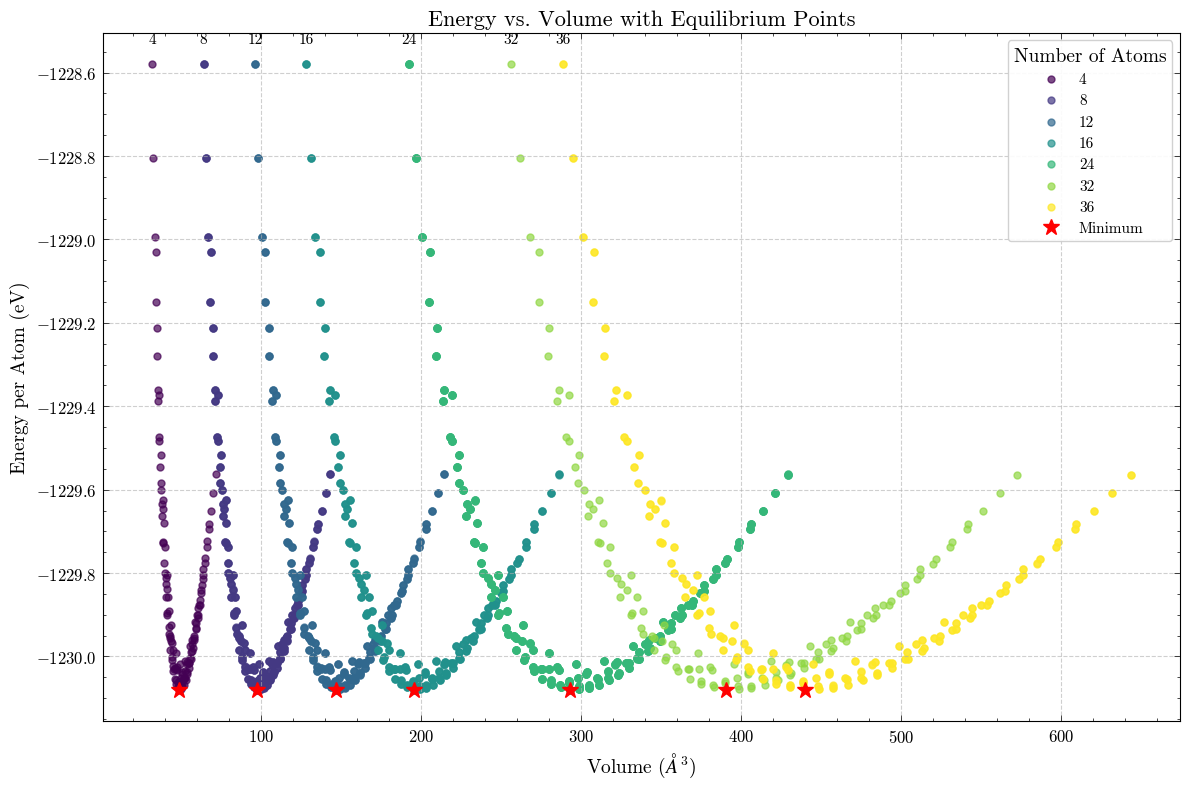

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

# Get the unique atom counts to loop through
unique_atom_counts = sorted(db_energia['num_atomos'].unique())

# Generate a unique color for each group from a colormap
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_atom_counts)))

# This flag ensures the "Minimum" label appears only once in the legend
min_legend_added = False

# Loop through each group of atoms
for i, num_atoms in enumerate(unique_atom_counts):
    # Create a subset of the data for the current group
    df_group = db_energia[db_energia['num_atomos'] == num_atoms]

    # Plot the main scatter points for this group
    ax.scatter(
        x=df_group['Volume_A³'],
        y=df_group['E/atom'],
        color=colors[i],
        label=str(num_atoms),
        s=25,
        alpha=0.7
    )

    # --- Annotation Logic for Atom Count ---
    min_volume = df_group['Volume_A³'].min()
    points_at_min_vol = df_group[df_group['Volume_A³'] == min_volume]
    annotation_point = points_at_min_vol.loc[points_at_min_vol['E/atom'].idxmax()]
    ax.text(
        x=annotation_point['Volume_A³'],
        y=annotation_point['E/atom'] + 0.05,
        s=str(num_atoms),
        color='black',
        fontweight='bold',
        fontsize=11,
        ha='center'
    )

    # --- Mark the Minimum Energy Point ---
    # Find the point with the lowest energy in the current group
    min_energy_point = df_group.loc[df_group['E/atom'].idxmin()]

    # Plot a special marker at that point
    ax.plot(
        min_energy_point['Volume_A³'],
        min_energy_point['E/atom'],
        marker='*',
        markersize=12,
        color='red',
        linestyle='none',
        label='Minimum' if not min_legend_added else "",
        zorder=10
    )
    # Set the flag to True so the label isn't repeated
    min_legend_added = True

# --- Final Plot Formatting ---
ax.set_xlabel('Volume ($\AA^3$)', fontsize=14)
ax.set_ylabel('Energy per Atom (eV)', fontsize=14)
ax.set_title('Energy vs. Volume with Equilibrium Points', fontsize=16)
ax.grid(True, linestyle='--', alpha=0.6)

# --- THE FIX: Manually reorder the legend items ---
# Get all the handles and labels that were created during plotting
handles, labels = ax.get_legend_handles_labels()

# Find the index of the 'Minimum' label
min_label_index = labels.index('Minimum')

# Pop the 'Minimum' handle and label from their original positions
min_handle = handles.pop(min_label_index)
min_label = labels.pop(min_label_index)

# Append them to the end of the lists
handles.append(min_handle)
labels.append(min_label)

# Now, create the legend with the reordered items
legend = ax.legend(
    handles, labels, # Pass the reordered lists
    title='Number of Atoms',
    fontsize=11,
    frameon=True,
    facecolor='white',
    framealpha=0.9
)

# Set the font size for the legend's title
legend.get_title().set_fontsize('14')

plt.tight_layout()
plt.show()

In [ ]:
db_atomo.head()

,sim_id,supercelula,num_atomos,atom_id,atom_type,energia_total_eV,Volume_A³,energia_total_Ry,Volume_(a.u)^3,fx_Ry_bohr,fy_Ry_bohr,fz_Ry_bohr,modulo_Ry_bohr,modulo_eV_A,label_atom
0,ZnO-2.94-1.45-111,1x1x1,4,atom 1,1,-4914.318818,32.064749,-361.195774,216.383651,-0.0,-0.0,-0.216244,0.216244,5.559852,Zn
1,ZnO-2.94-1.45-111,1x1x1,4,atom 2,1,-4914.318818,32.064749,-361.195774,216.383651,0.0,0.0,-0.216244,0.216244,5.559852,Zn
2,ZnO-2.94-1.45-111,1x1x1,4,atom 3,2,-4914.318818,32.064749,-361.195774,216.383651,0.0,0.0,0.216244,0.216244,5.559852,O
3,ZnO-2.94-1.45-111,1x1x1,4,atom 4,2,-4914.318818,32.064749,-361.195774,216.383651,0.0,0.0,0.216244,0.216244,5.559852,O
4,ZnO-2.94-1.49-111,1x1x1,4,atom 1,1,-4915.220202,32.777295,-361.262024,221.192150,-0.0,-0.0,-0.153782,0.153782,3.953906,Zn


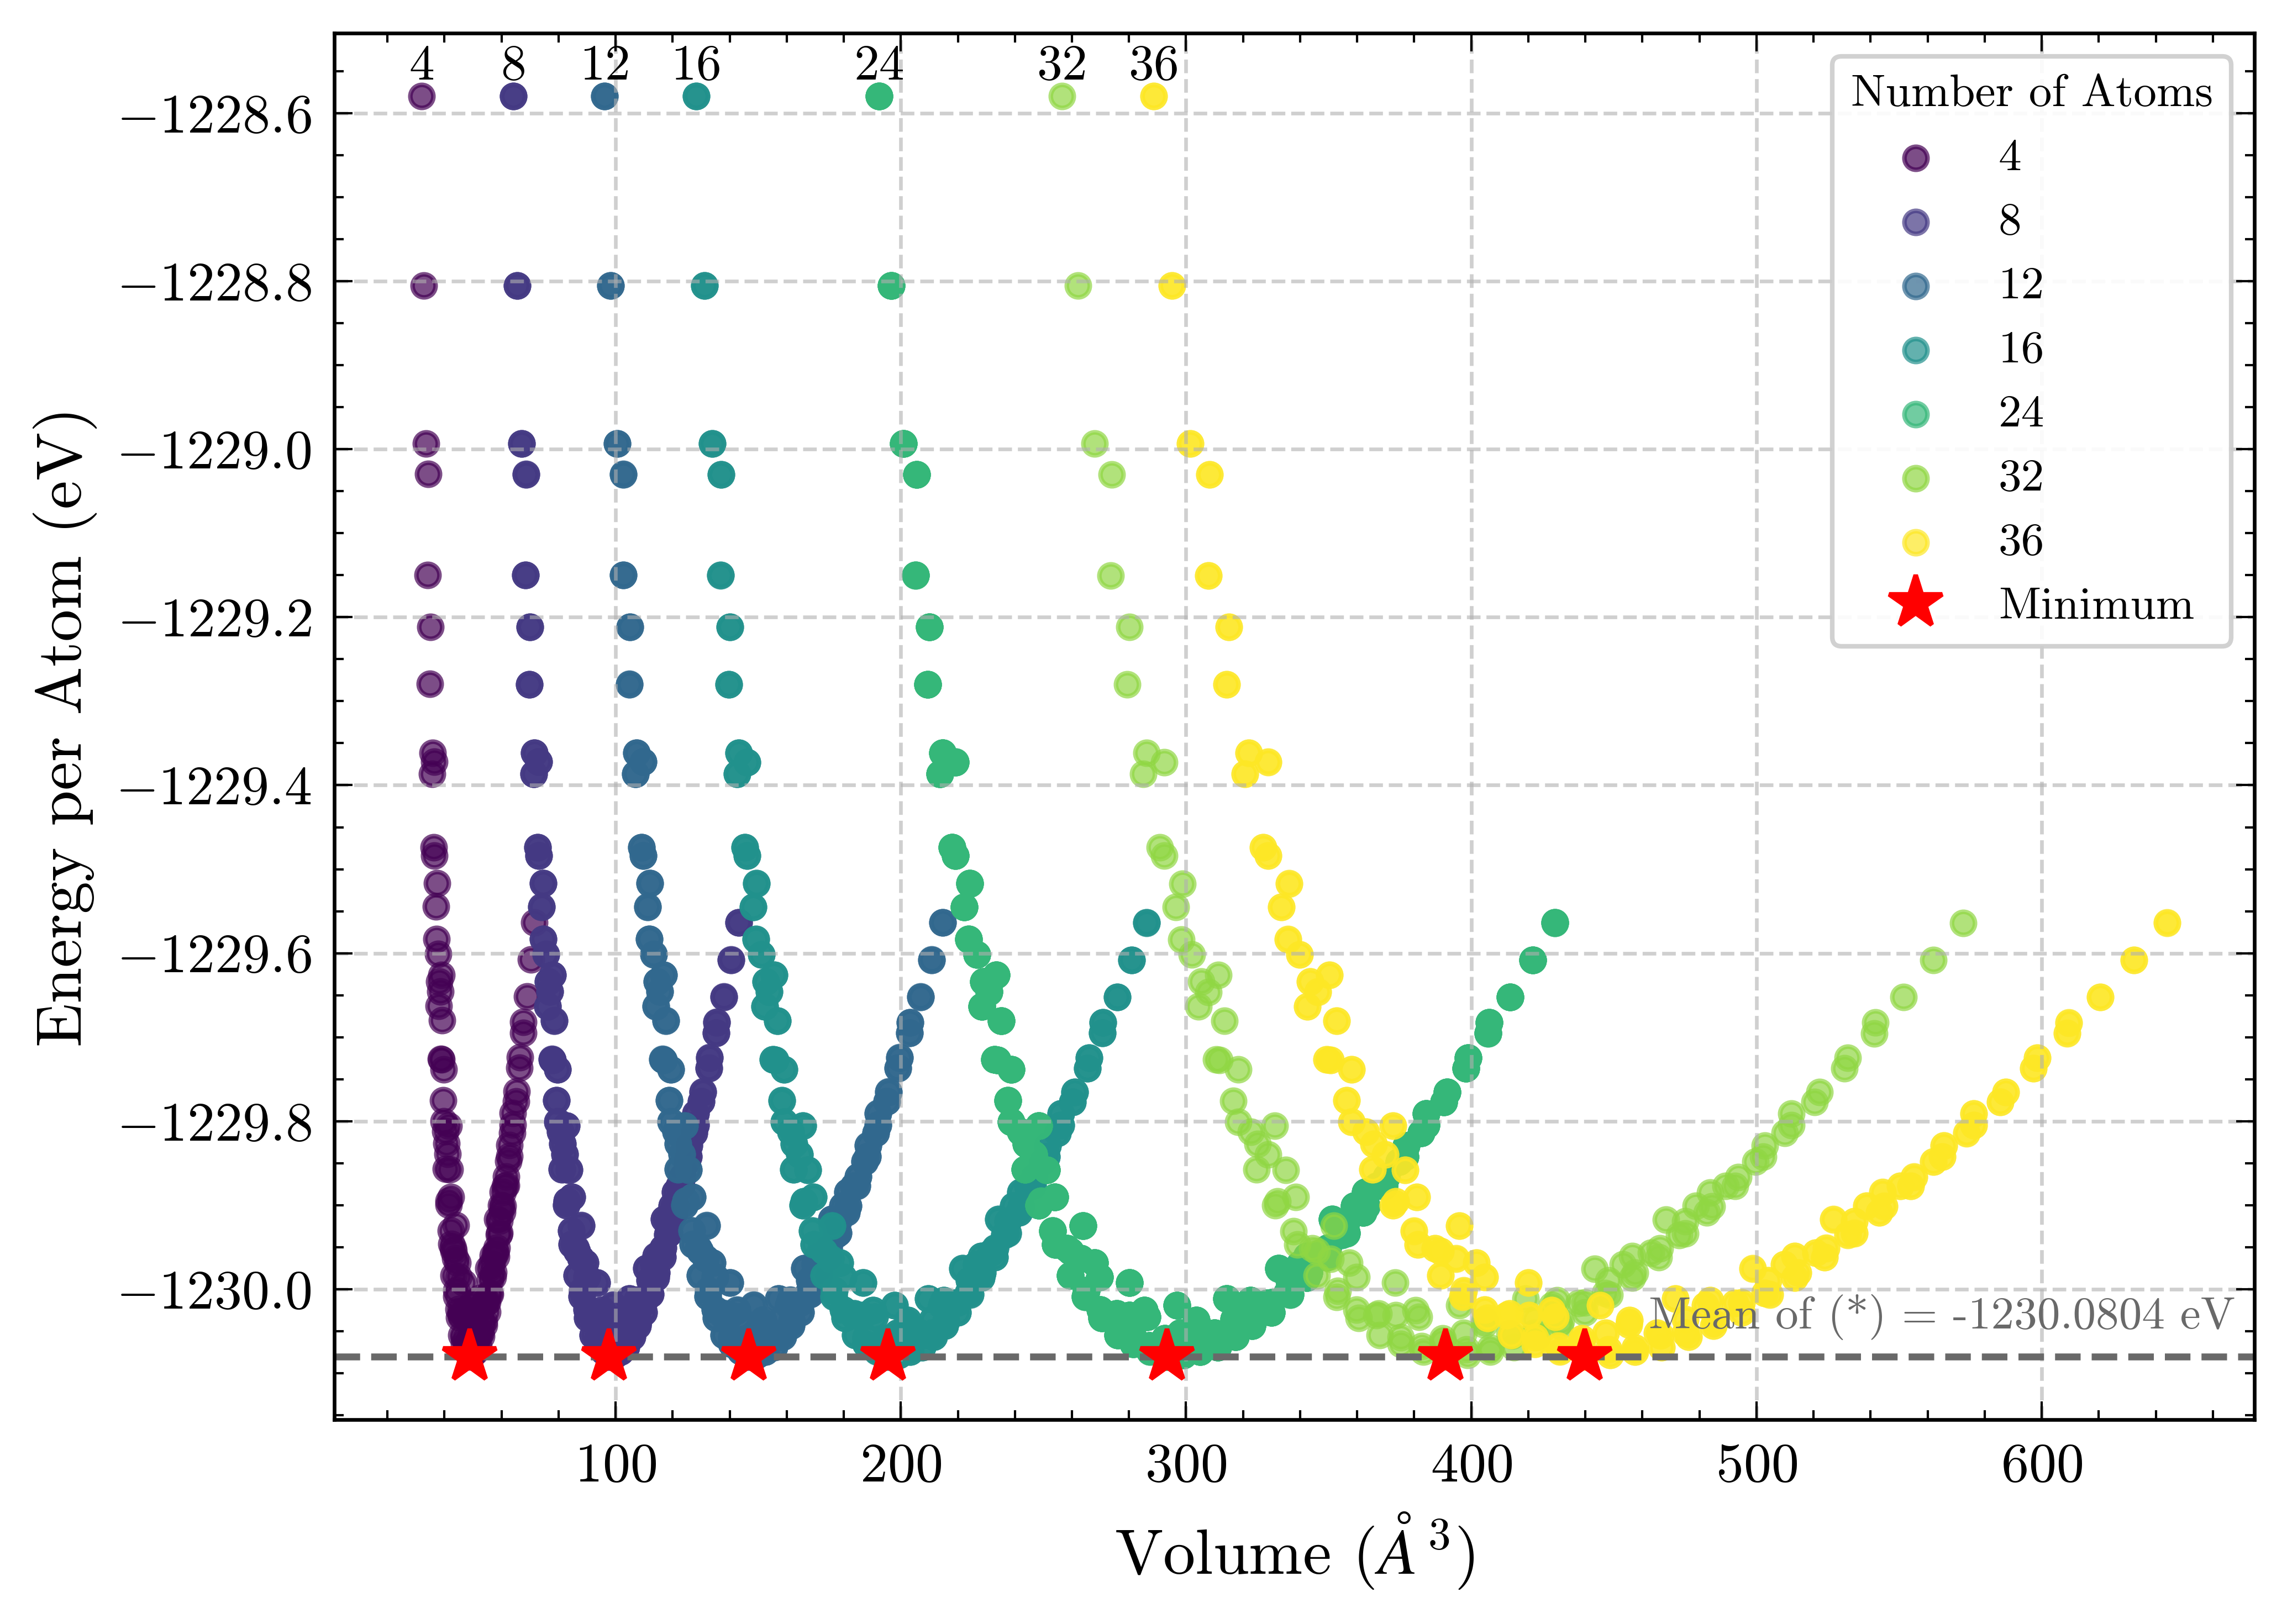

In [22]:
# --- Plotting Code ---

fig, ax = plt.subplots(figsize=(7, 5), dpi=600)

# Get the unique atom counts to loop through
unique_atom_counts = sorted(db_energia['num_atomos'].unique())

# Generate a unique color for each group from a colormap
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_atom_counts)))

# This flag ensures the "Minimum" label appears only once in the legend
min_legend_added = False
# This list will store the minimum energy for each curve
min_energy_values = []

# Loop through each group of atoms
for i, num_atoms in enumerate(unique_atom_counts):
    # Create a subset of the data for the current group
    df_group = db_energia[db_energia['num_atomos'] == num_atoms]

    # Plot the main scatter points for this group
    ax.scatter(
        x=df_group['Volume_A³'],
        y=df_group['E/atom'],
        color=colors[i],
        label=str(num_atoms),
        s=25,
        alpha=0.7
    )

    # --- Annotation Logic for Atom Count ---
    min_volume = df_group['Volume_A³'].min()
    points_at_min_vol = df_group[df_group['Volume_A³'] == min_volume]
    annotation_point = points_at_min_vol.loc[points_at_min_vol['E/atom'].idxmax()]
    ax.text(
        x=annotation_point['Volume_A³'],
        y=annotation_point['E/atom'] + 0.02,
        s=str(num_atoms),
        color='black',
        fontweight='bold',
        fontsize=11,
        ha='center'
    )

    # --- Mark the Minimum Energy Point ---
    # Find the point with the lowest energy
    min_energy_point = df_group.loc[df_group['E/atom'].idxmin()]
    # Store its value for later
    min_energy_values.append(min_energy_point['E/atom'])

    # Plot a special marker at that point
    ax.plot(
        min_energy_point['Volume_A³'],
        min_energy_point['E/atom'],
        marker='*',
        markersize=12,
        color='red',
        linestyle='none',
        label='Minimum' if not min_legend_added else "",
        zorder=10
    )
    # Set the flag to True so the label isn't repeated
    min_legend_added = True

# --- Final Plot Formatting ---
ax.set_xlabel('Volume ($\AA^3$)', fontsize=14)
ax.set_ylabel('Energy per Atom (eV)', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.6)

# --- NEW: Add the Mean Line and Annotation ---
# Calculate the mean of the collected minimum energies
mean_min_energy = np.mean(min_energy_values)

# Plot the horizontal line
ax.axhline(
    y=mean_min_energy,
    color='dimgray',
    linestyle='--',
    linewidth=1.5
)

# Add the annotation text on the right side
ax.text(
    x=ax.get_xlim()[1] * 0.99, # Position at 99% of the plot's width
    y=mean_min_energy + 0.02,  # Position slightly above the line
    s=f'Mean of (*) = {mean_min_energy:.4f} eV',
    color='dimgray',
    fontweight='bold',
    ha='right', # Horizontally align to the right
    va='bottom' # Vertically align to the bottom
)


# --- Manually reorder the legend items ---
handles, labels = ax.get_legend_handles_labels()
min_label_index = labels.index('Minimum')
min_handle = handles.pop(min_label_index)
min_label = labels.pop(min_label_index)
handles.append(min_handle)
labels.append(min_label)

# Create the legend with the reordered items
legend = ax.legend(
    handles, labels,
    title='Number of Atoms',
    fontsize=10,
    frameon=True,
    facecolor='white',
    framealpha=0.9
)

# Set the font size for the legend's title
legend.get_title().set_fontsize('10')
plt.savefig('energyXnum_atoms.png', dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [ ]:
db_simulacao.shape

(2299, 12)

In [ ]:
db_simulacao['Volume_A³'].unique().size


2220

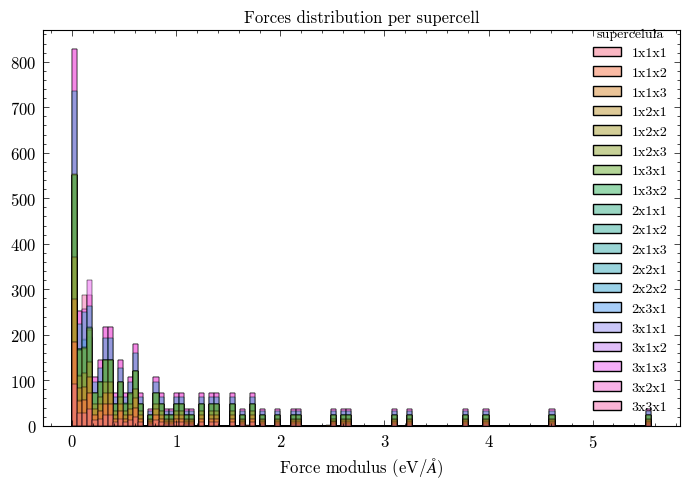

In [ ]:
fig = plt.figure(figsize=(7,5))
ax = sns.histplot(data=db_atomo, x="modulo_eV_A", hue="supercelula")
plt.title(f"Forces distribution per supercell")

plt.ylabel("")
plt.xlabel("Force modulus (eV/$\AA$)")


plt.tight_layout()
plt.show()